# Analyse et Traitement des Données Climatiques 2024

Ce notebook combine l'analyse exploratoire et le traitement des données climatiques.

## Partie 1: Analyse Exploratoire
Visualisations et statistiques descriptives des données brutes et standardisées.

### Imports et Configuration

In [1]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from functools import reduce

# Configuration des graphiques
plt.rcParams['figure.dpi'] = 100
sns.set(style="whitegrid")

### Paramètres Globaux

In [2]:
CLIP_DIR = r"C:\Users\Y A N I S\Desktop\set\output_clips"
types = ["prec", "tmin", "tmax"]
months = [f"{i:02d}" for i in range(1, 13)]

groupes = [
    ["01", "02", "03"],  # Hiver
    ["04", "05", "06"],  # Printemps
    ["07", "08", "09"],  # Été
    ["10", "11", "12"]   # Automne
]

season_dict = {
    "hiver": ["01", "02", "03"],
    "printemps": ["04", "05", "06"],
    "ete": ["07", "08", "09"],
    "automne": ["10", "11", "12"]
}

### 1️⃣ Récupération des Données

In [3]:
all_files = {var: sorted(glob.glob(os.path.join(CLIP_DIR, f"{var}_2024-*_clip.tif"))) for var in types}
data_dict = {var: {} for var in types}

for var in types:
    for f in all_files[var]:
        mois_str = os.path.basename(f).split("_")[1]
        with rasterio.open(f) as src:
            arr = src.read(1)
            arr_valid = arr[arr > 0]
            data_dict[var][mois_str] = arr_valid

print("✅ Données chargées avec succès")

✅ Données chargées avec succès


### 2️⃣ Aperçu des Valeurs Brutes

In [4]:
print("--- Exemples de valeurs brutes ---")
for var in types:
    for mois in months[:2]:
        mois_str = f"2024-{mois}"
        arr = data_dict[var].get(mois_str, np.array([]))
        if arr.size > 0:
            print(f"{var} - {mois_str} : {arr[:10]}")
            print(f"Stats {var} {mois_str} : min={np.min(arr):.2f}, median={np.median(arr):.2f}, max={np.max(arr):.2f}")

--- Exemples de valeurs brutes ---
prec - 2024-01 : [50.6   50.15  48.075 45.525 42.9   40.975 54.35  52.875 49.85  50.05 ]
Stats prec 2024-01 : min=0.08, median=1.62, max=139.12
prec - 2024-02 : [103.7   103.3   100.375  96.95   93.05   89.375 109.05  107.85  103.3
 104.625]
Stats prec 2024-02 : min=0.12, median=2.10, max=266.15
tmin - 2024-01 : [9.   9.   8.5  8.25 8.25 8.25 9.   8.5  8.5  8.  ]
Stats tmin 2024-01 : min=0.25, median=6.00, max=12.00
tmin - 2024-02 : [9.   9.   8.5  8.5  8.5  8.75 9.   9.   9.   8.25]
Stats tmin 2024-02 : min=0.25, median=8.50, max=14.00
tmax - 2024-01 : [17.   16.5  16.5  16.75 16.75 17.   17.   17.   17.   16.25]
Stats tmax 2024-01 : min=6.25, median=20.25, max=28.00
tmax - 2024-02 : [17.   17.   17.   17.   17.25 17.   17.   17.   17.   17.  ]
Stats tmax 2024-02 : min=7.25, median=23.25, max=30.00


### 3️⃣ Histogrammes Avant/Après Standardisation

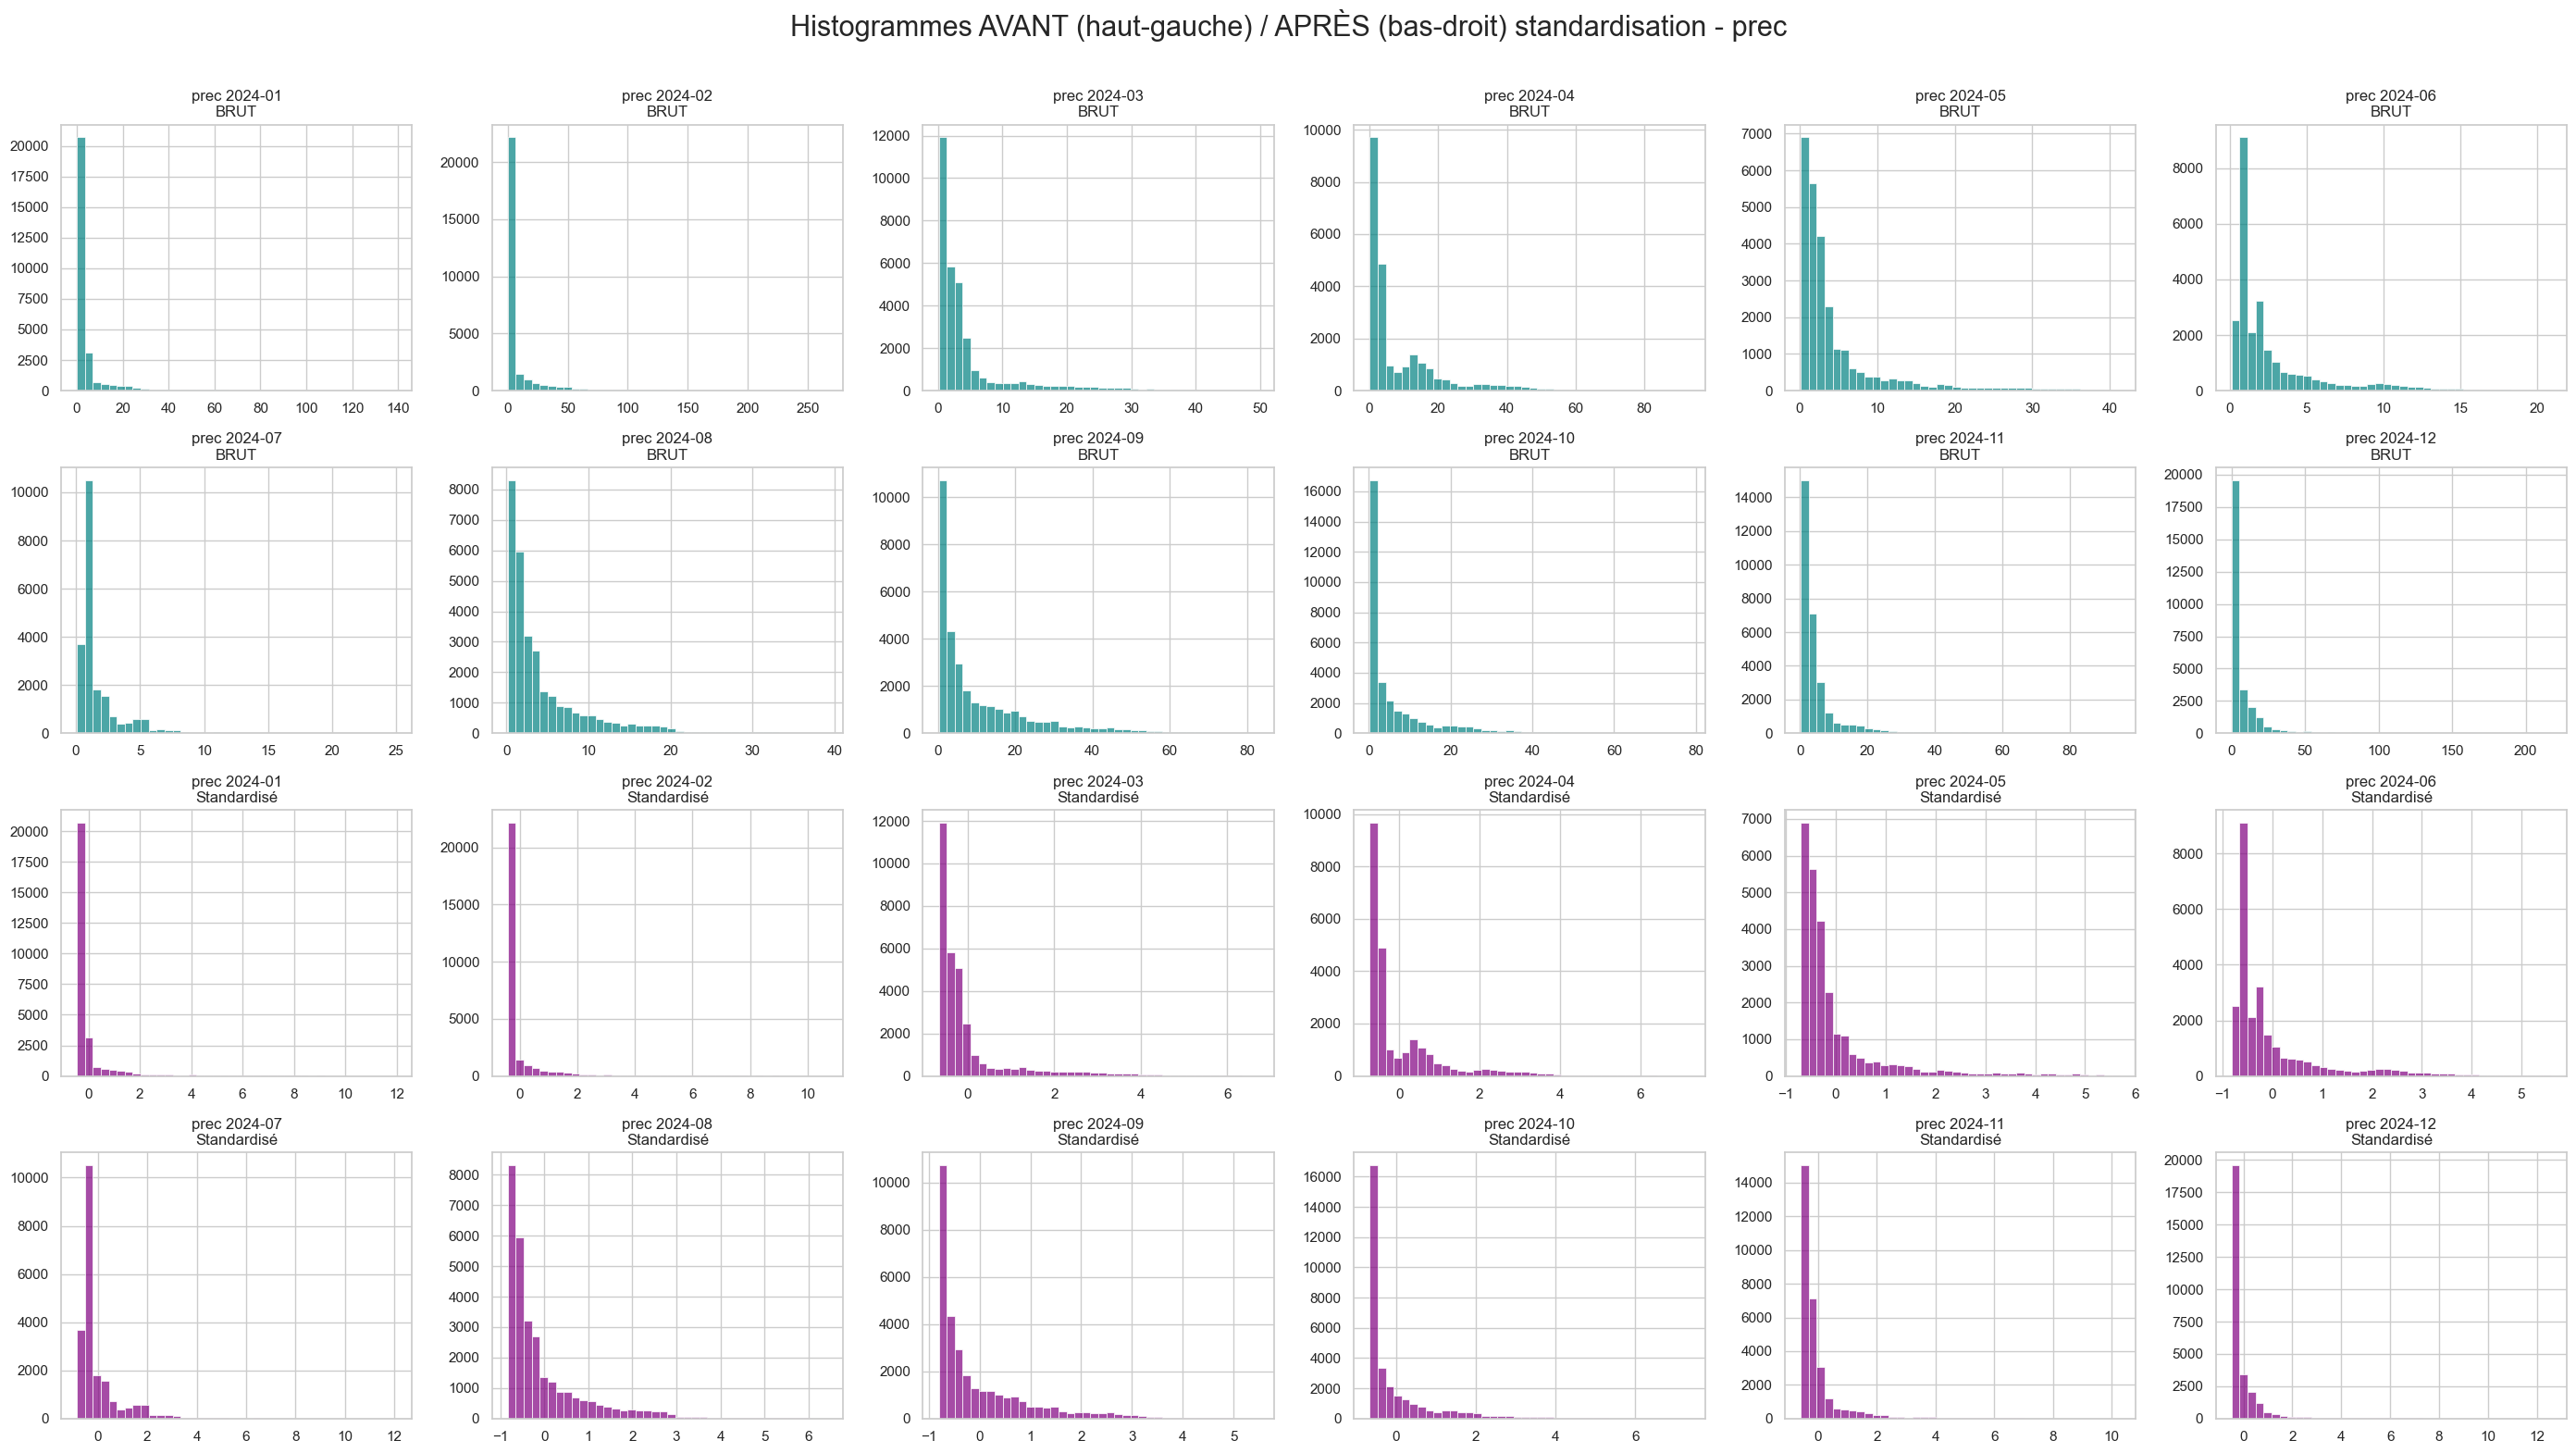

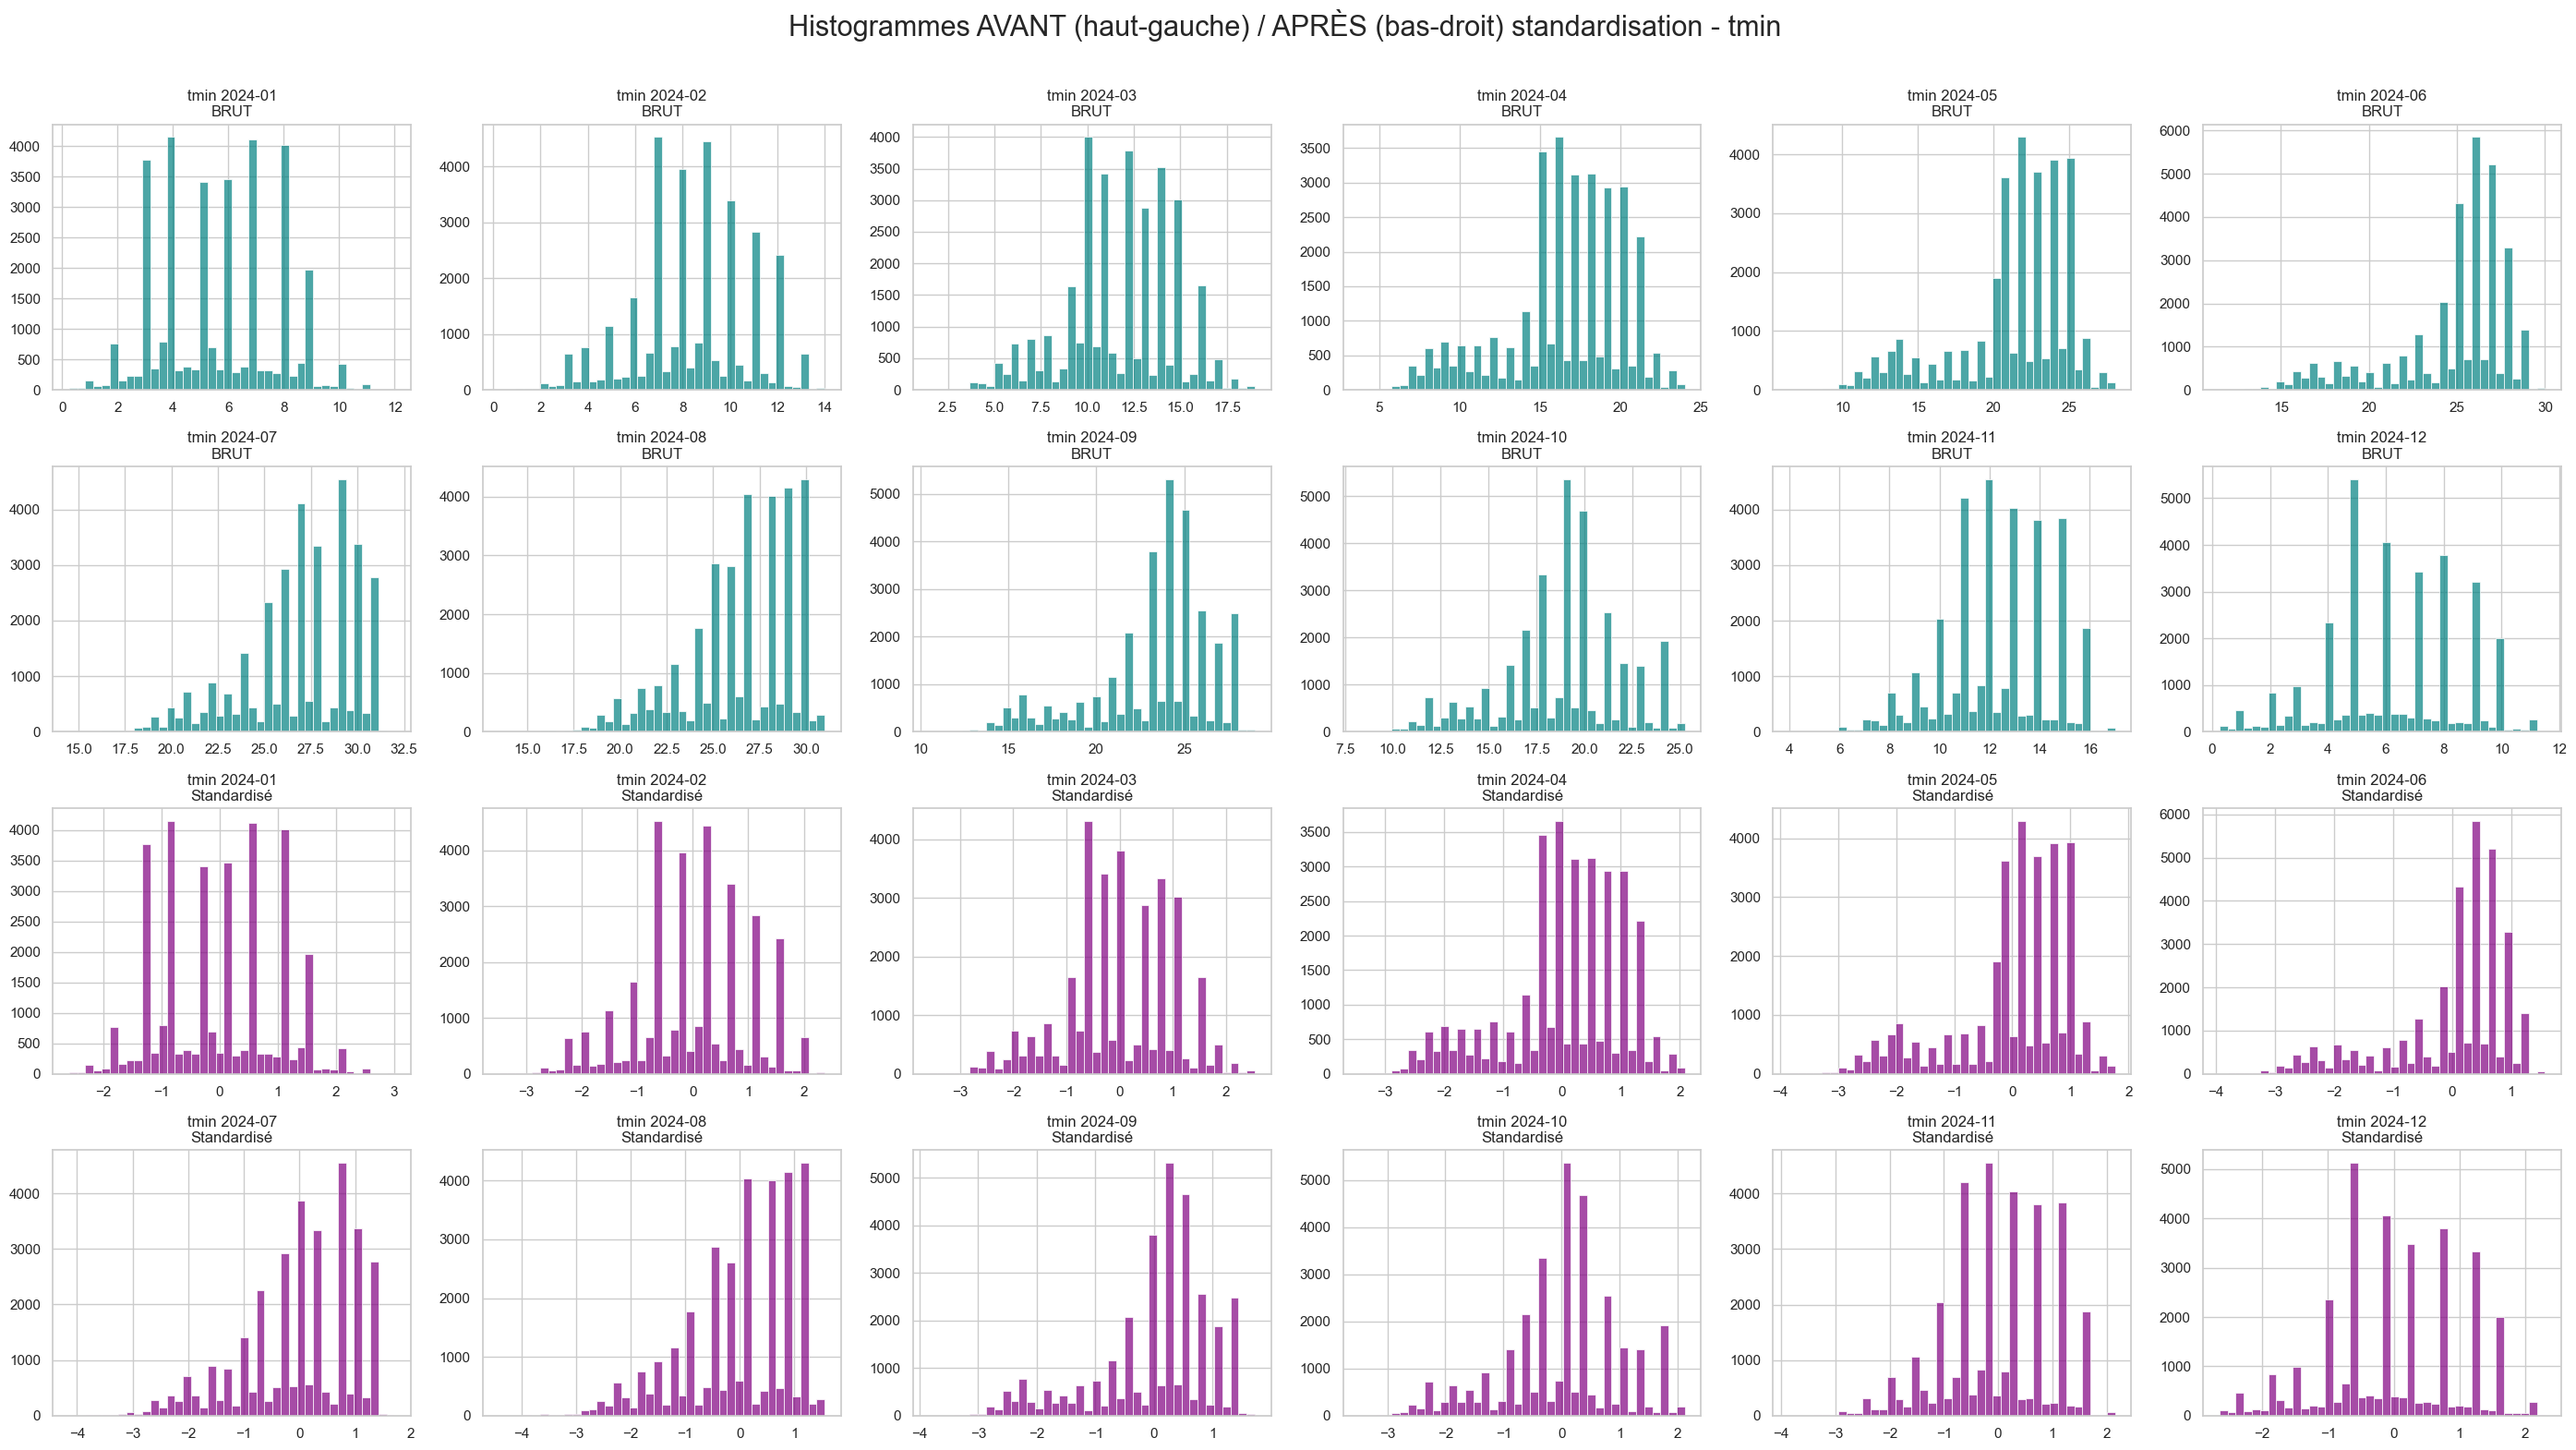

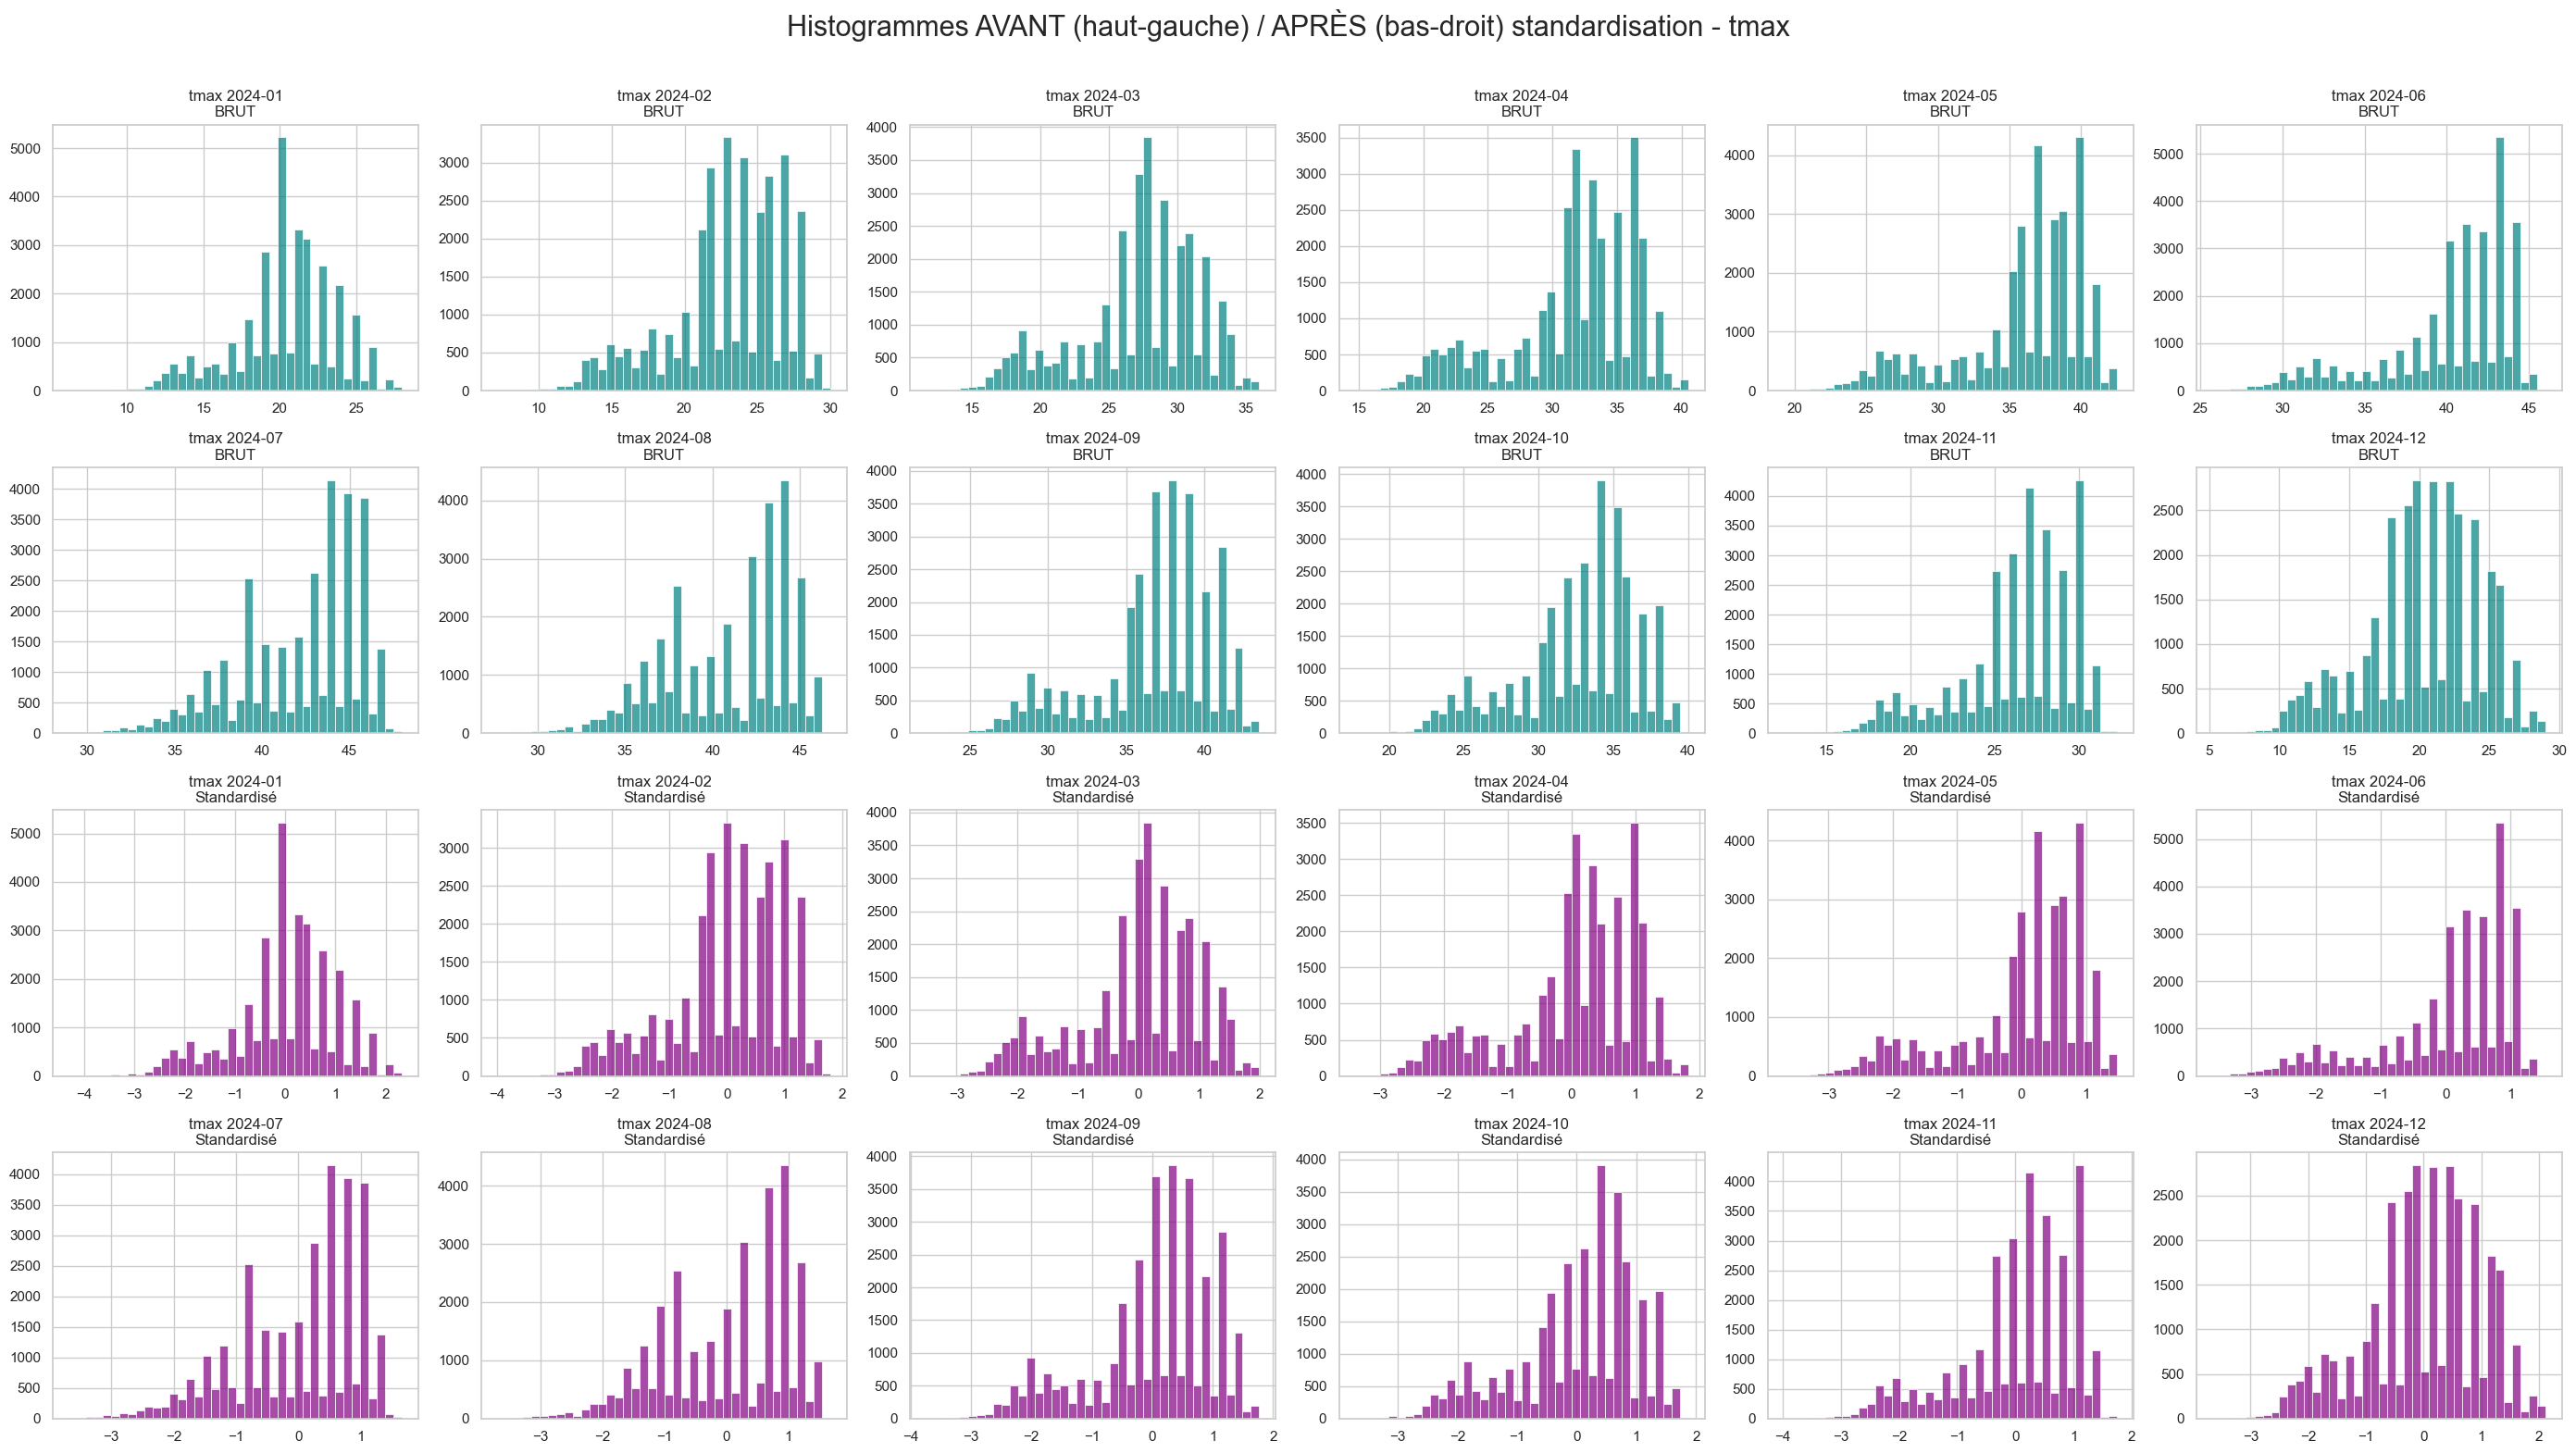

In [5]:
for var in types:
    fig, axs = plt.subplots(4, 6, figsize=(28, 16))
    
    # Première moitié : AVANT standardisation
    for i, mois in enumerate(months):
        mois_str = f"2024-{mois}"
        arr = data_dict[var].get(mois_str, np.array([]))
        ax = axs[i//6, i%6]
        if arr.size > 0:
            sns.histplot(arr, bins=40, color="teal", alpha=0.7, ax=ax)
            ax.set_title(f"{var} {mois_str}\nBRUT")
        else:
            ax.set_title(f"{var} {mois_str}\nNoData")
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    # Deuxième moitié : APRÈS standardisation
    for i, mois in enumerate(months):
        mois_str = f"2024-{mois}"
        arr = data_dict[var].get(mois_str, np.array([]))
        j = i + 12
        ax = axs[j//6, j%6]
        if arr.size > 0:
            scaler = StandardScaler()
            arr_std = scaler.fit_transform(arr.reshape(-1,1)).flatten()
            sns.histplot(arr_std, bins=40, color="purple", alpha=0.7, ax=ax)
            ax.set_title(f"{var} {mois_str}\nStandardisé")
        else:
            ax.set_title(f"{var} {mois_str}\nNoData")
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    fig.suptitle(f"Histogrammes AVANT (haut-gauche) / APRÈS (bas-droit) standardisation - {var}", fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

### 4️⃣ Boxplots par Saison

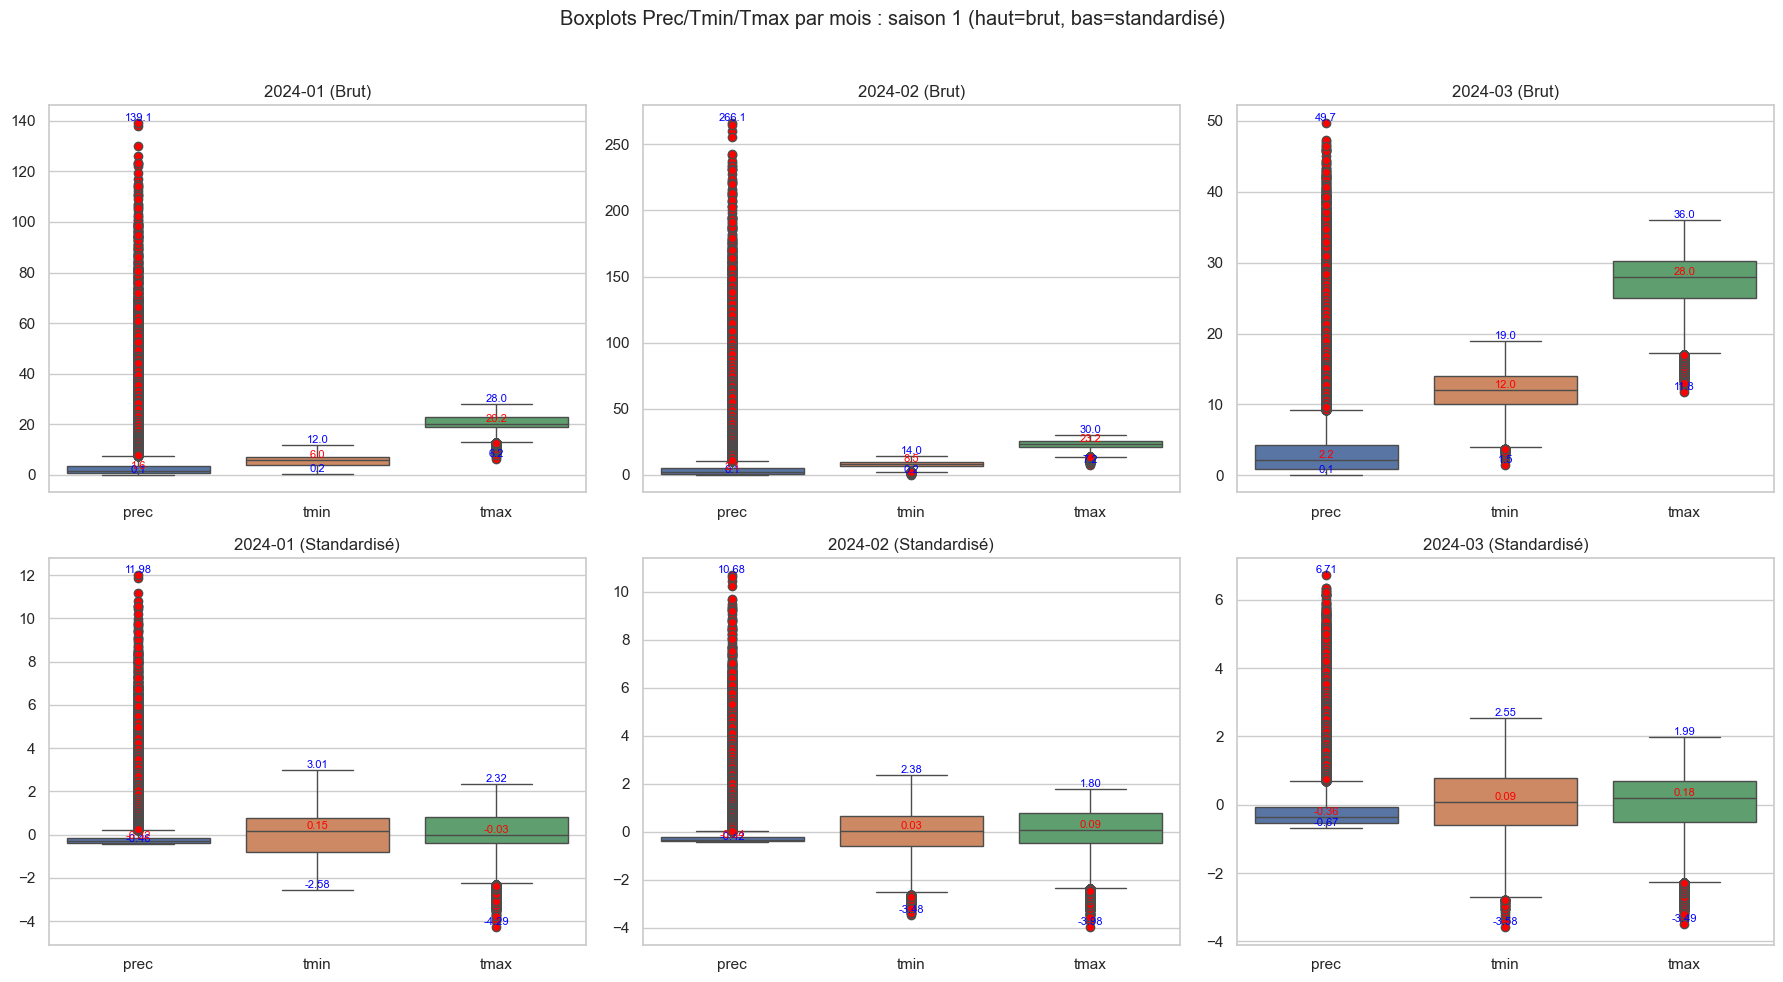

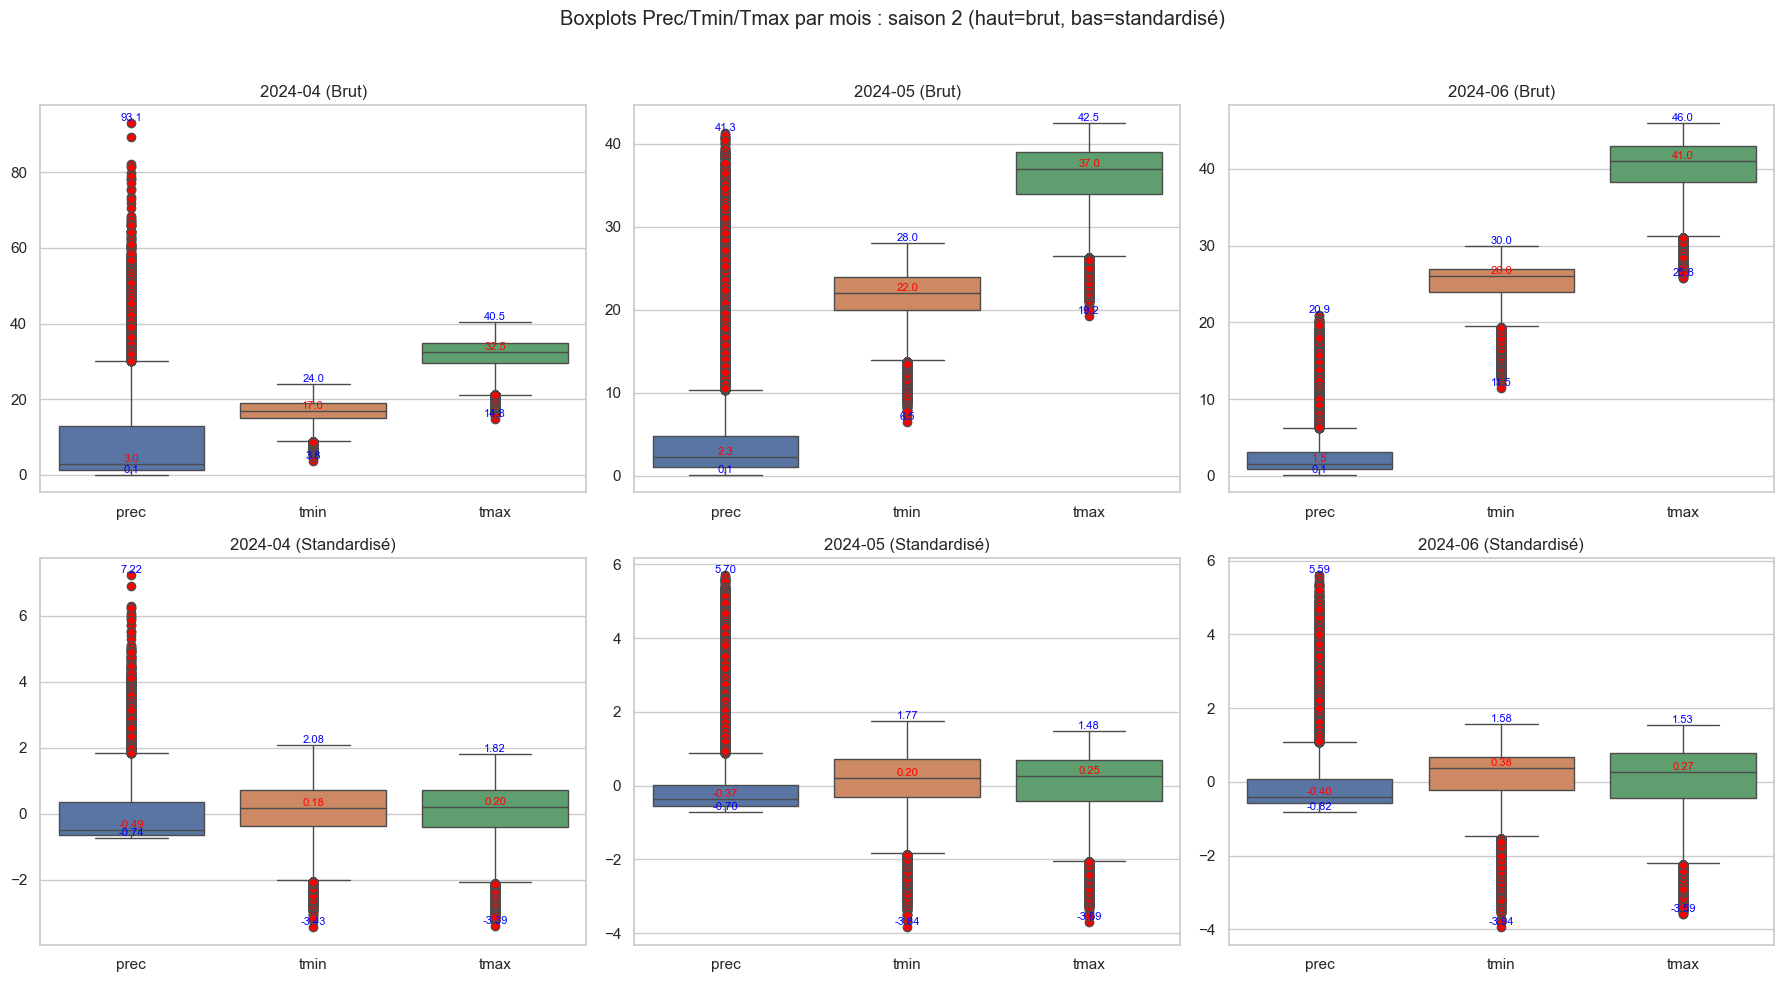

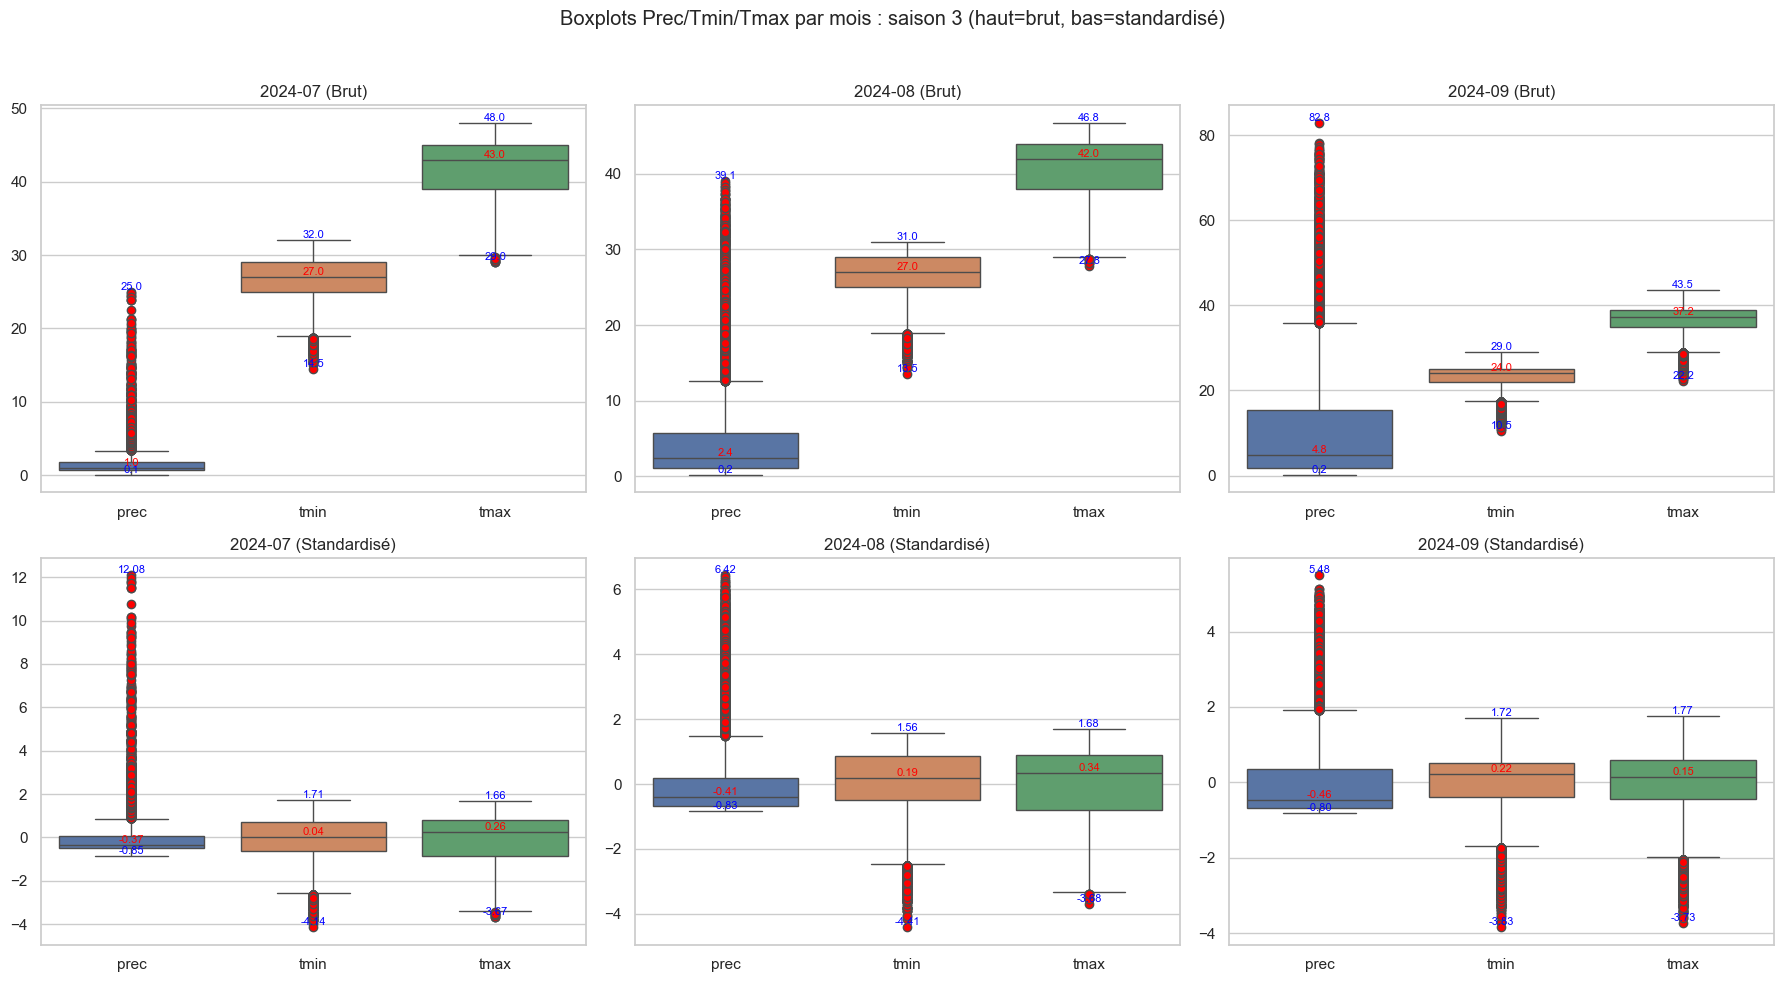

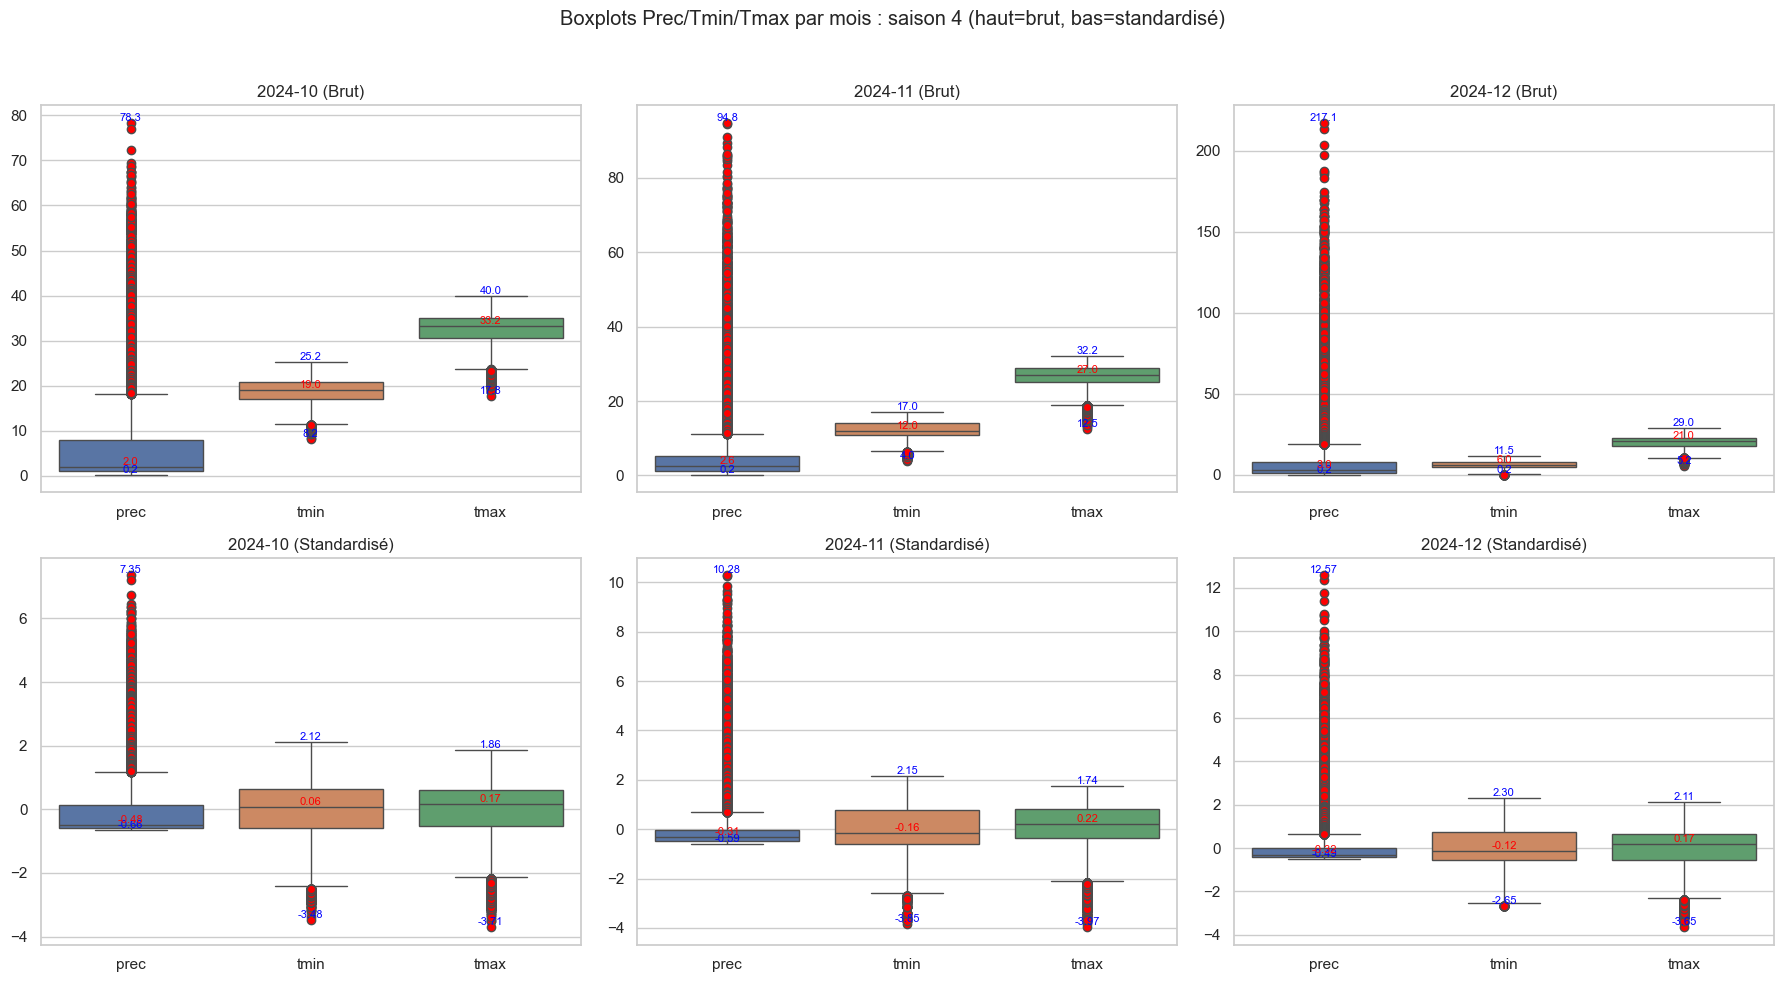

In [6]:
for saison, trio in enumerate(groupes):
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    for idx, mois in enumerate(trio):
        mois_str = f"2024-{mois}"
        arrs_brut, arrs_std, var_labels = [], [], []
        
        for var in types:
            arr = data_dict[var].get(mois_str, np.array([]))
            if arr.size > 0:
                arrs_brut.append(arr)
                scaler = StandardScaler()
                arr_std = scaler.fit_transform(arr.reshape(-1,1)).flatten()
                arrs_std.append(arr_std)
                var_labels.append(var)
        
        ax_brut = axs[0, idx]
        ax_std = axs[1, idx]
        
        if arrs_brut:
            sns.boxplot(data=arrs_brut, flierprops={'marker': 'o', 'markerfacecolor': 'red'}, ax=ax_brut)
            ax_brut.set_xticks(range(len(var_labels)))
            ax_brut.set_xticklabels(var_labels)
            ax_brut.set_title(f"{mois_str} (Brut)")
            
            for i, arr in enumerate(arrs_brut):
                ax_brut.text(i, np.min(arr), f"{np.min(arr):.1f}", ha="center", va="bottom", color="blue", fontsize=8)
                ax_brut.text(i, np.median(arr), f"{np.median(arr):.1f}", ha="center", va="bottom", color="red", fontsize=8)
                ax_brut.text(i, np.max(arr), f"{np.max(arr):.1f}", ha="center", va="bottom", color="blue", fontsize=8)
            
            sns.boxplot(data=arrs_std, flierprops={'marker': 'o', 'markerfacecolor': 'red'}, ax=ax_std)
            ax_std.set_xticks(range(len(var_labels)))
            ax_std.set_xticklabels(var_labels)
            ax_std.set_title(f"{mois_str} (Standardisé)")
            
            for i, arr in enumerate(arrs_std):
                ax_std.text(i, np.min(arr), f"{np.min(arr):.2f}", ha="center", va="bottom", color="blue", fontsize=8)
                ax_std.text(i, np.median(arr), f"{np.median(arr):.2f}", ha="center", va="bottom", color="red", fontsize=8)
                ax_std.text(i, np.max(arr), f"{np.max(arr):.2f}", ha="center", va="bottom", color="blue", fontsize=8)
        else:
            ax_brut.set_title(f"{mois_str}\nNoData")
            ax_std.set_title(f"{mois_str}\nNoData")
    
    plt.suptitle(f"Boxplots Prec/Tmin/Tmax par mois : saison {saison+1} (haut=brut, bas=standardisé)")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### 5️⃣ QQ-Plots (Test de Normalité)

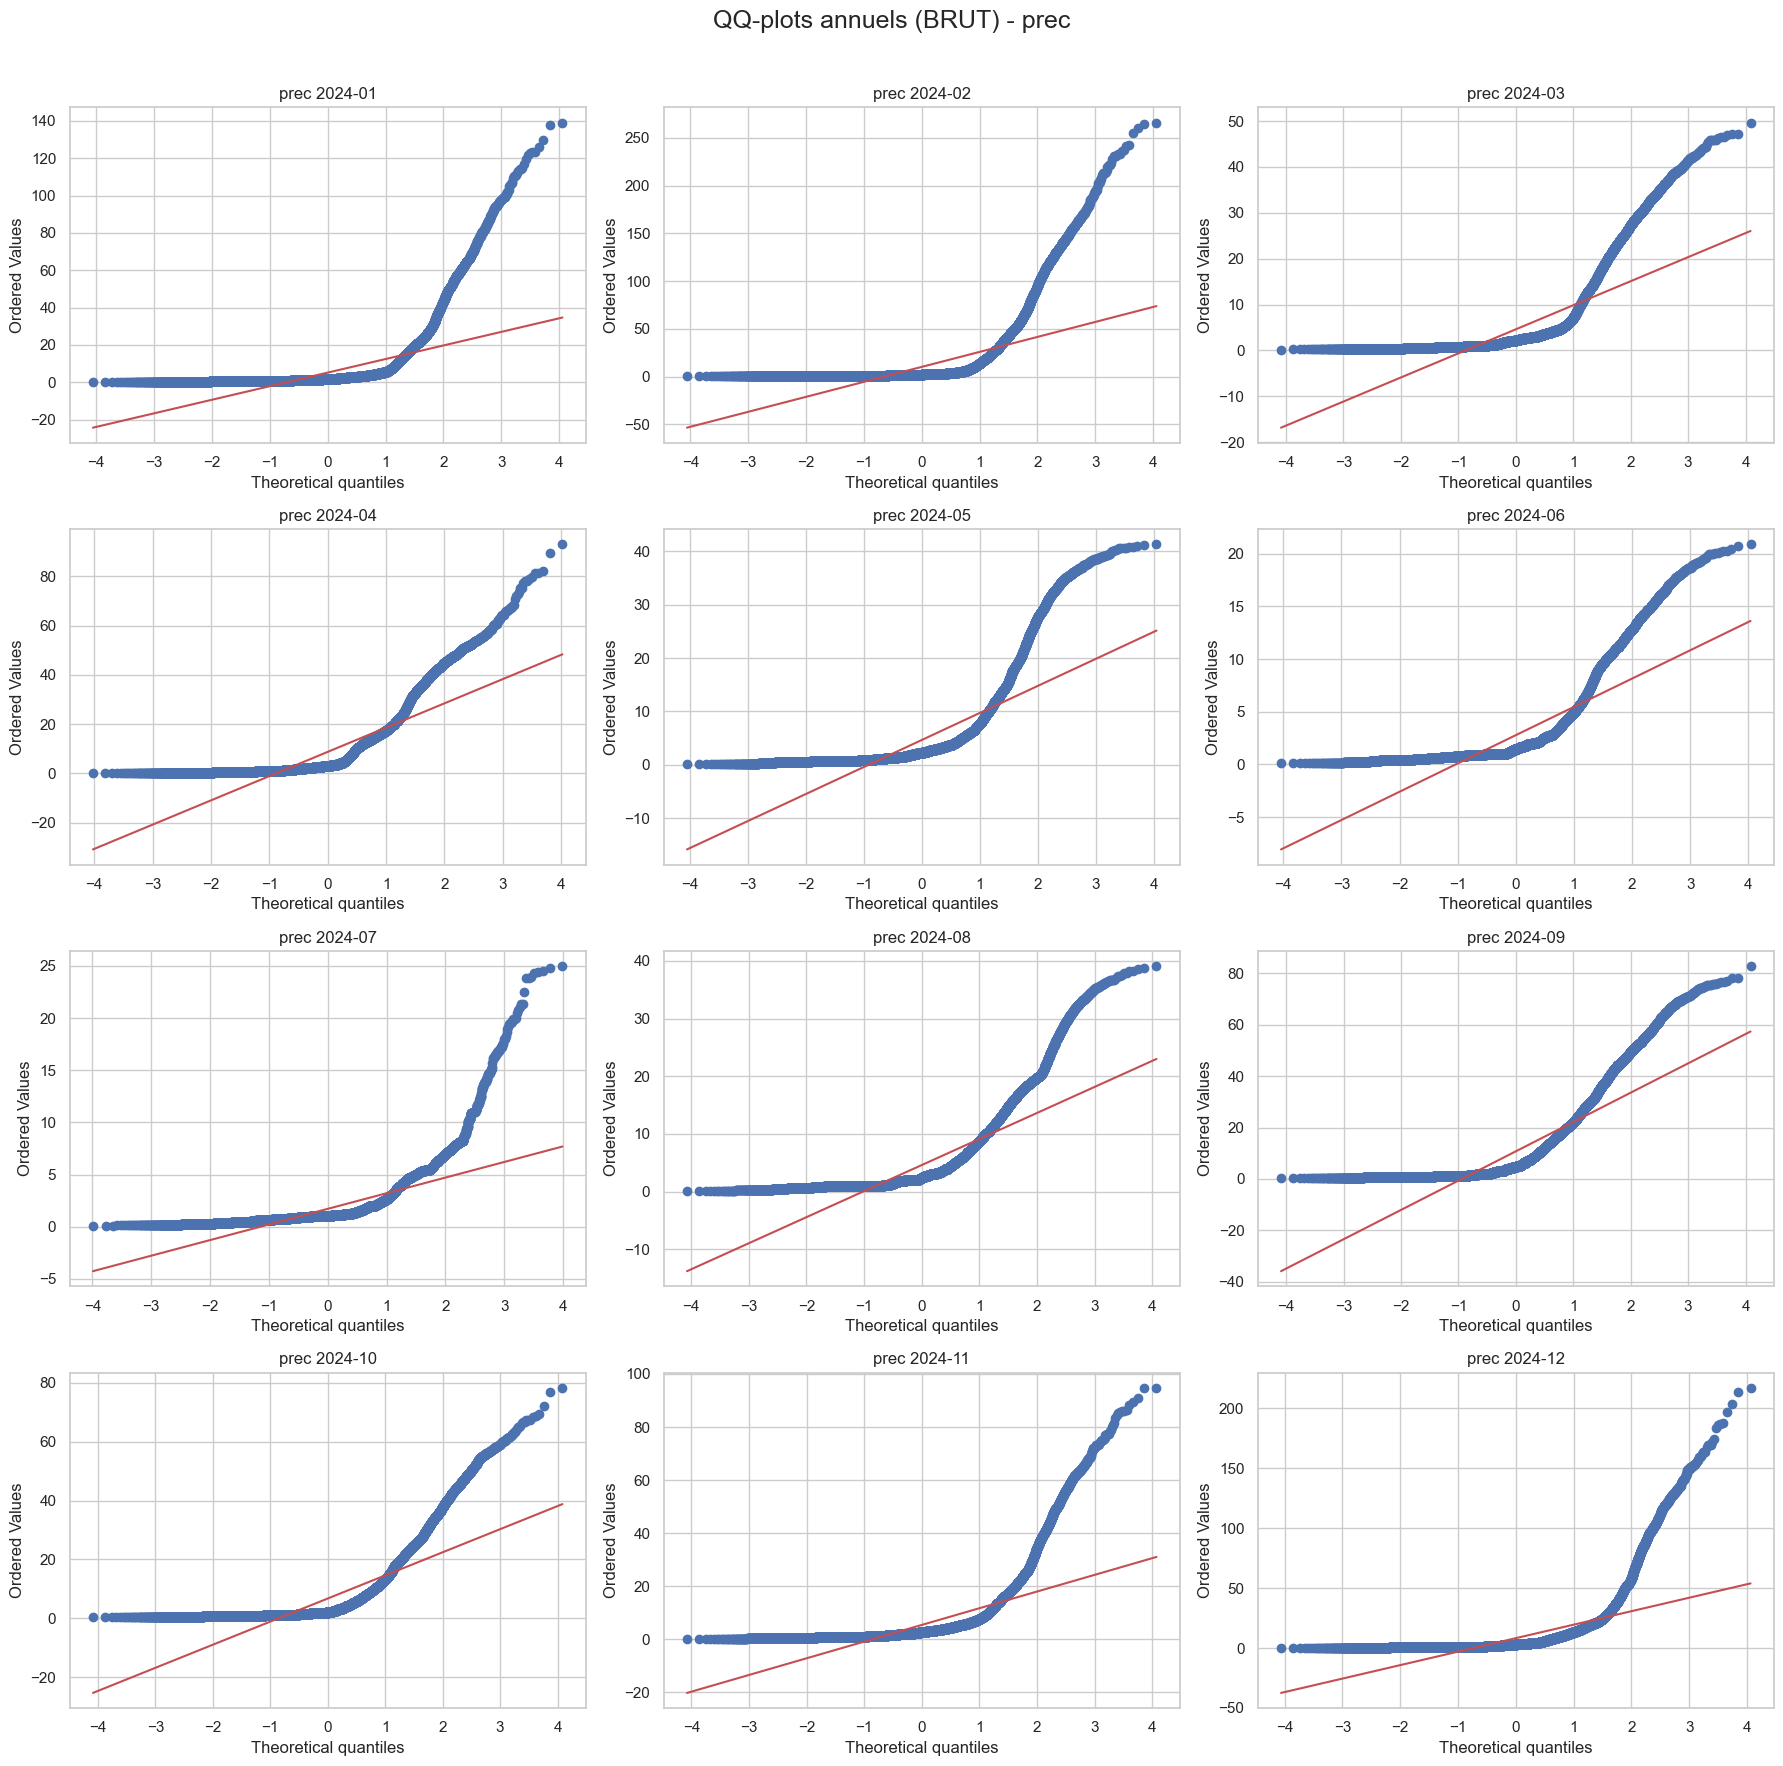

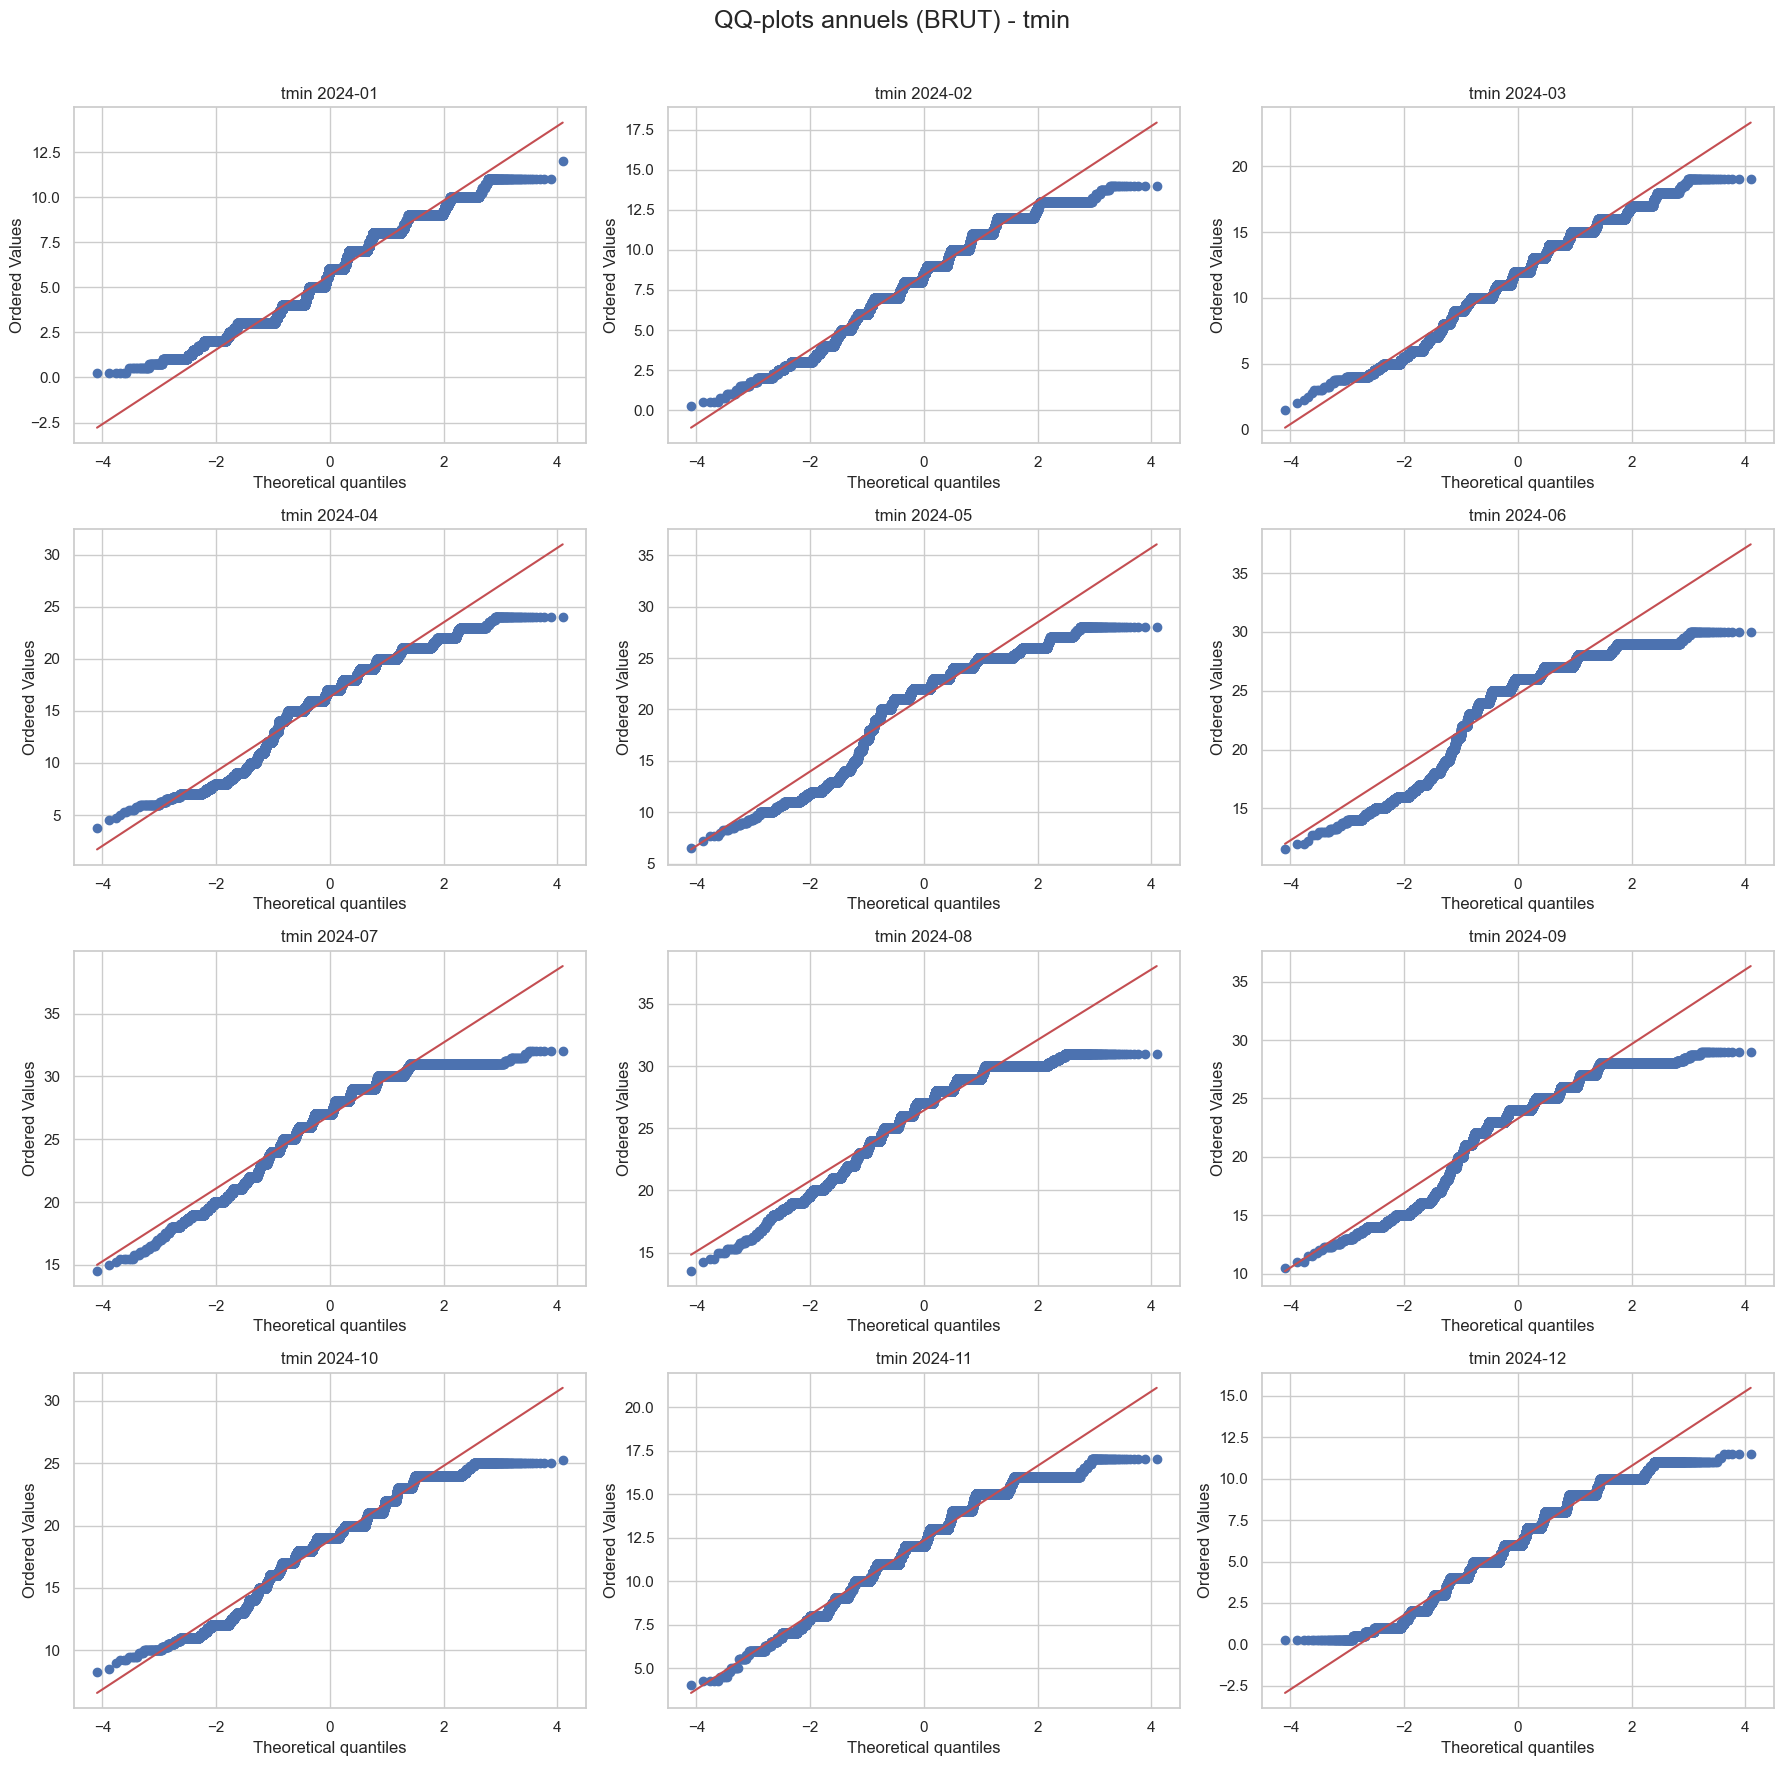

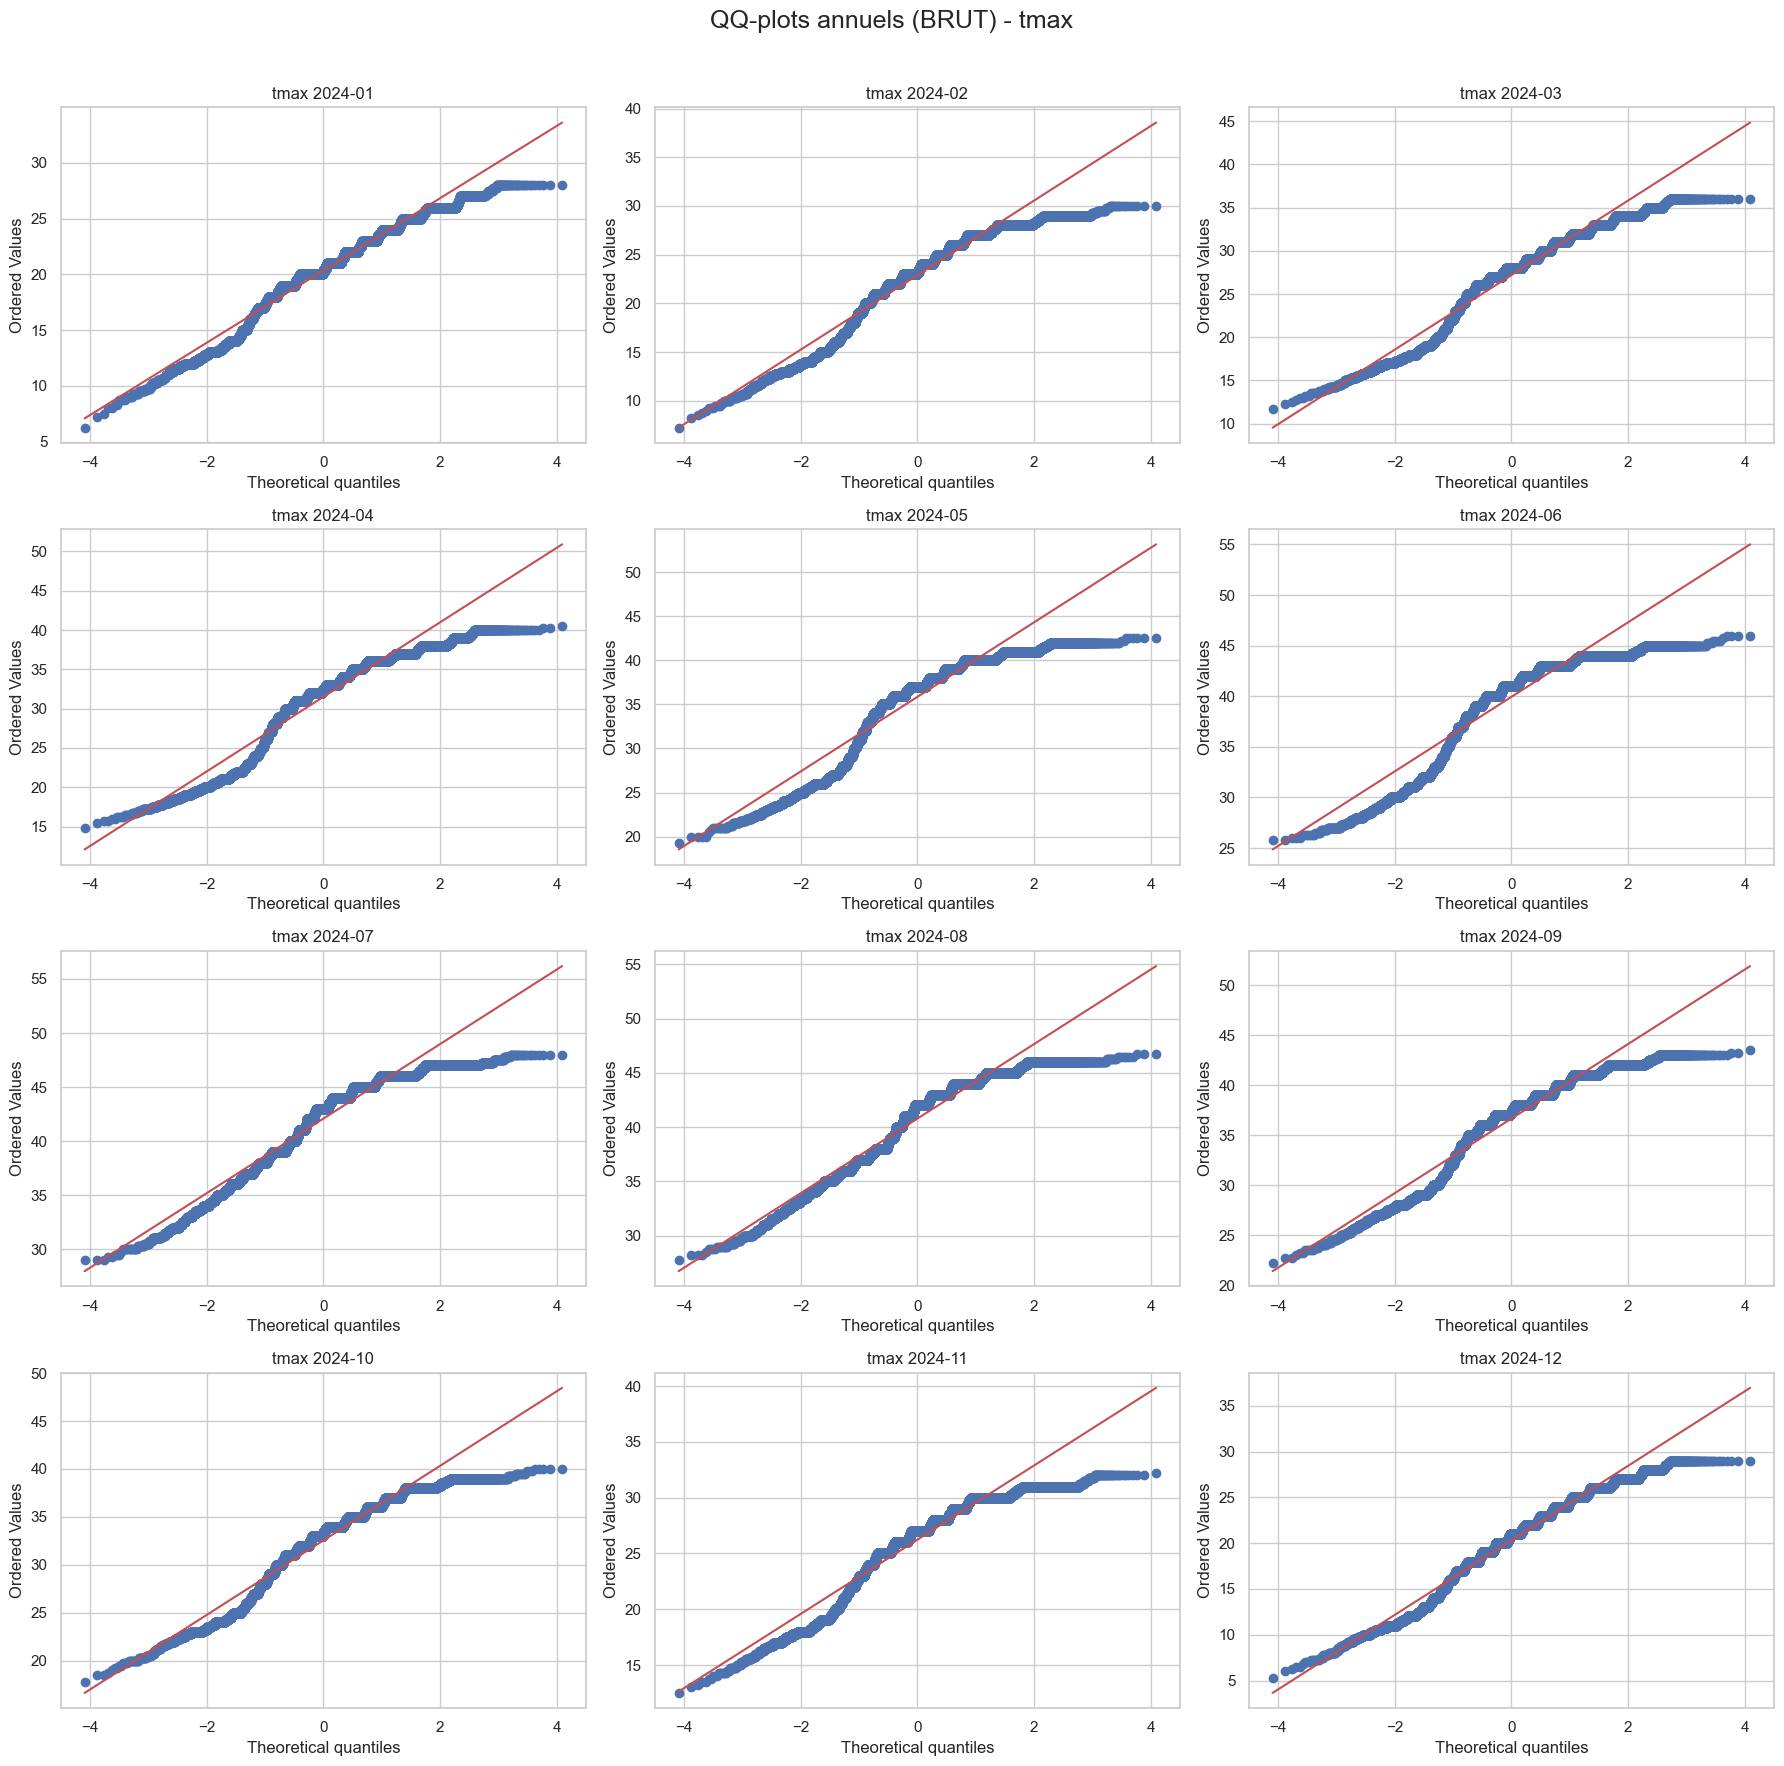

In [7]:
for var in types:
    fig, axs = plt.subplots(4, 3, figsize=(18, 18))
    
    for i, mois in enumerate(months):
        mois_str = f"2024-{mois}"
        arr = data_dict[var].get(mois_str, np.array([]))
        ax = axs[i//3, i%3]
        
        if arr.size > 0:
            stats.probplot(arr, dist="norm", plot=ax)
            ax.set_title(f"{var} {mois_str}")
        else:
            ax.set_title(f"{var} {mois_str}\nNoData")
        ax.grid(True)
    
    fig.suptitle(f"QQ-plots annuels (BRUT) - {var}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

### 6️⃣ Scatterplots Tmax vs Prec

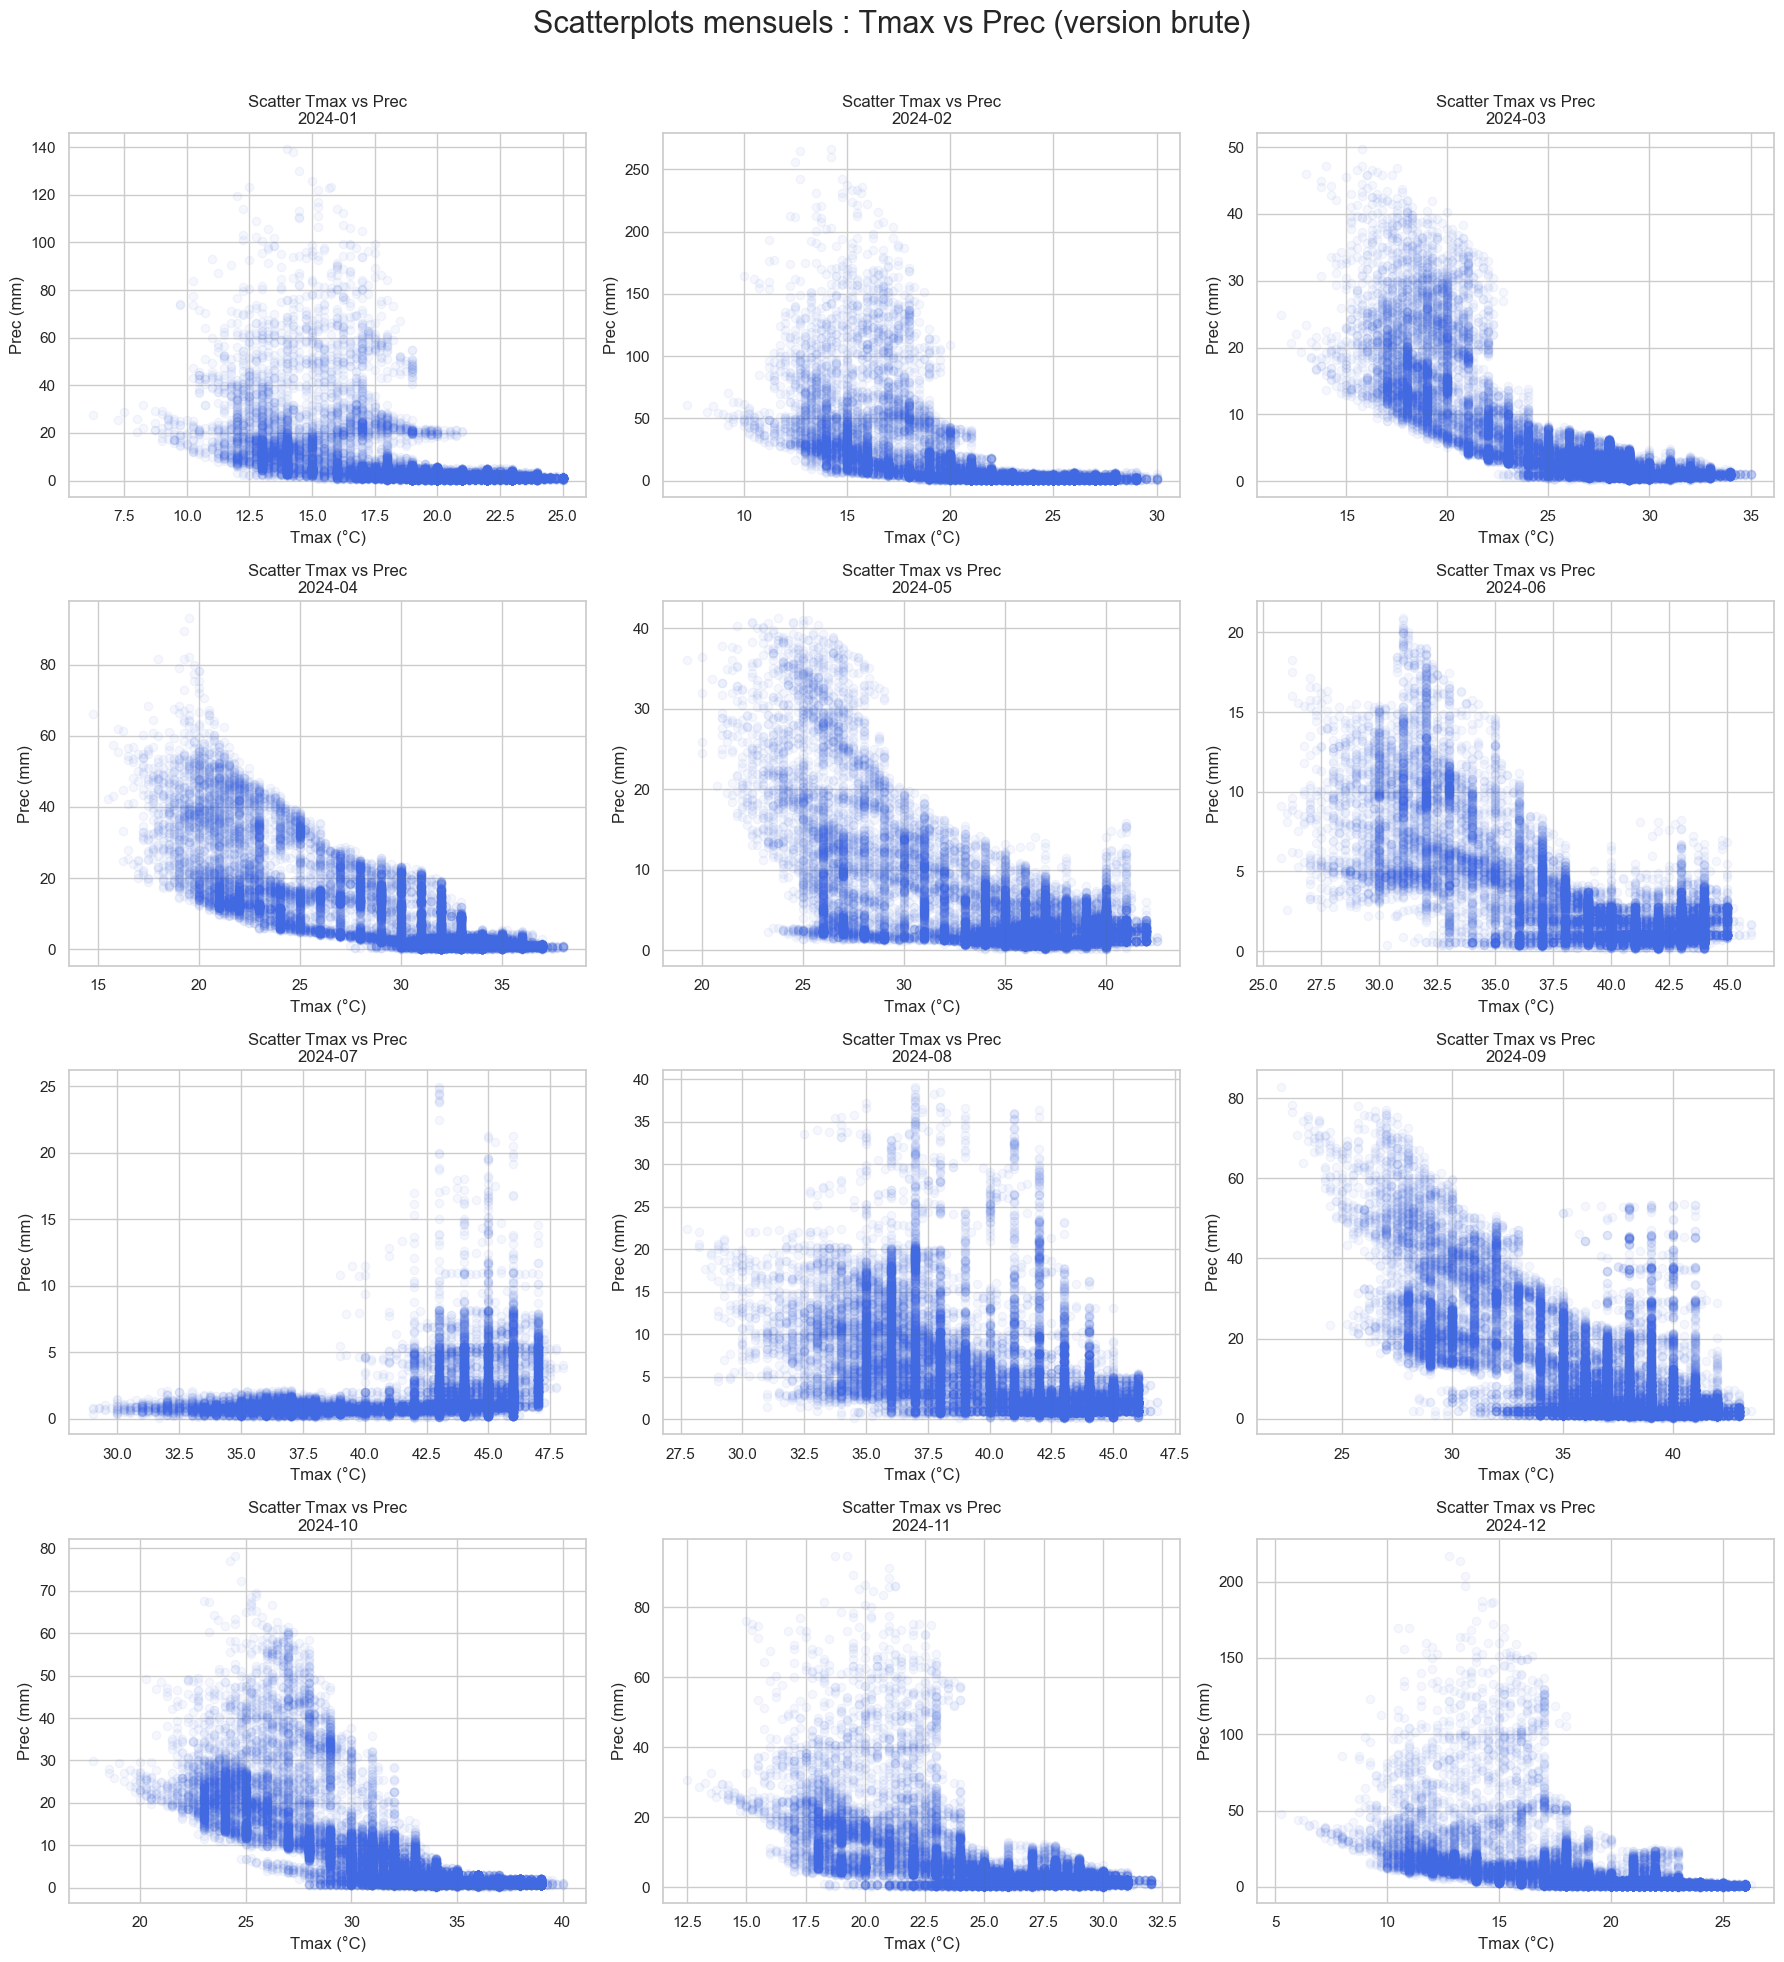

In [8]:
fig, axs = plt.subplots(4, 3, figsize=(18, 20))

for i, mois in enumerate(months):
    mois_str = f"2024-{mois}"
    arr_prec = data_dict["prec"].get(mois_str, np.array([]))
    arr_tmax = data_dict["tmax"].get(mois_str, np.array([]))
    min_len = min(len(arr_prec), len(arr_tmax))
    ax = axs[i//3, i%3]
    
    if min_len > 0:
        ax.scatter(arr_tmax[:min_len], arr_prec[:min_len], color="royalblue", alpha=0.05)
        ax.set_title(f"Scatter Tmax vs Prec\n{mois_str}")
        ax.set_xlabel("Tmax (°C)")
        ax.set_ylabel("Prec (mm)")
    else:
        ax.set_title(f"{mois_str}\nNoData")
    ax.grid(True)

fig.suptitle("Scatterplots mensuels : Tmax vs Prec (version brute)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
## Partie 2: Traitement et Export des Données

Extraction des valeurs cappées (1%-99%) et calcul des moyennes saisonnières.

### Extraction des Valeurs Cappées par Raster

In [9]:
clip_dir = CLIP_DIR  # Réutilisation du même répertoire
data_per_type_month = {}

for var in types:
    data_per_type_month[var] = {}
    for month in months:
        fname = f"{var}_2024-{month}_clip.tif"
        fpath = os.path.join(clip_dir, fname)
        
        if os.path.exists(fpath):
            with rasterio.open(fpath) as src:
                arr = src.read(1)
                valid_mask = ~np.isnan(arr)
                rows, cols = np.where(valid_mask)
                xs, ys = rasterio.transform.xy(src.transform, rows, cols)
                values = arr[rows, cols]
                
                # Capping 1%-99%
                q01 = np.nanpercentile(values, 1)
                q99 = np.nanpercentile(values, 99)
                values_capped = np.clip(values, q01, q99)
                
                # Sauvegarde par pixel
                for x, y, val in zip(xs, ys, values_capped):
                    key = (x, y)
                    if key not in data_per_type_month[var]:
                        data_per_type_month[var][key] = {}
                    data_per_type_month[var][key][month] = val
        else:
            print(f"⚠️ Fichier absent : {fpath}")

print("✅ Extraction des valeurs cappées terminée")

✅ Extraction des valeurs cappées terminée


### Génération du DataFrame avec Moyennes Saisonnières

In [10]:
# Intersection des points communs à toutes les variables
common_keys = set.intersection(
    *(set(data_per_type_month[var].keys()) for var in types)
)
print(f"Nombre de points communs à toutes les variables : {len(common_keys)}")

# Calcul des moyennes saisonnières
seasonal_data = []
for key in common_keys:
    row = {'X': key[0], 'Y': key[1]}
    for var in types:
        for season, mois in season_dict.items():
            vals = [data_per_type_month[var][key].get(m, np.nan) for m in mois]
            # Moyenne sur les mois de la saison
            row[f"{var}_{season}"] = np.mean(vals)
    seasonal_data.append(row)

df_season = pd.DataFrame(seasonal_data)

# Réorganisation des colonnes
cols_order = ["X", "Y"]
for var in types:
    for season in season_dict.keys():
        cols_order.append(f"{var}_{season}")
df_season = df_season[cols_order]

print("✅ DataFrame saisonnier créé")
print(df_season.head())

Nombre de points communs à toutes les variables : 32877
✅ DataFrame saisonnier créé
          X          Y  prec_hiver  prec_printemps  prec_ete  prec_automne  \
0 -3.208333  25.958333       0.300        0.000000  1.000000      1.625000   
1 -3.208333  25.208333       0.000        0.000000  1.000000      1.333333   
2 -3.208333  25.708333       0.000        0.000000  1.000000      1.466667   
3 -3.208333  25.458333       0.000        0.000000  1.000000      1.300000   
4  1.458333  21.791667       0.775        1.066667  8.708333      0.400000   

   tmin_hiver  tmin_printemps   tmin_ete  tmin_automne  tmax_hiver  \
0   11.333333       23.666666  28.833334     15.000000   26.750000   
1   12.666667       24.916666  29.833334     16.666666   28.333334   
2   11.666667       24.500000  29.083334     15.583333   27.166666   
3   12.666667       25.666666  29.833334     16.666666   27.916666   
4   11.833333       24.500000  26.500000     15.250000   29.333334   

   tmax_printemps   tmax_e

### Export du CSV Final

In [11]:
# Création du dossier output si nécessaire
os.makedirs("output", exist_ok=True)

# Export CSV
df_season.to_csv("output/rasters_seasonal_capped.csv", index=False, sep=';')
print("🎉 CSV saisonnier exporté : output/rasters_seasonal_capped.csv")
print(f"Dimensions : {df_season.shape}")
print(f"Colonnes : {list(df_season.columns)}")

🎉 CSV saisonnier exporté : output/rasters_seasonal_capped.csv
Dimensions : (32877, 14)
Colonnes : ['X', 'Y', 'prec_hiver', 'prec_printemps', 'prec_ete', 'prec_automne', 'tmin_hiver', 'tmin_printemps', 'tmin_ete', 'tmin_automne', 'tmax_hiver', 'tmax_printemps', 'tmax_ete', 'tmax_automne']


### Aperçu Final des Statistiques

In [12]:
print("\n--- Statistiques descriptives du DataFrame final ---")
print(df_season.describe())


--- Statistiques descriptives du DataFrame final ---
                  X             Y    prec_hiver  prec_printemps      prec_ete  \
count  32877.000000  32877.000000  32877.000000    32877.000000  32877.000000   
mean       3.058533     28.567647      5.639857        4.026039      5.167029   
std        4.537152      4.407356     11.745511        5.857990      5.440861   
min       -8.625000     19.125000      0.000000        0.000000      0.000000   
25%       -0.125000     25.041667      0.758333        0.700000      1.116667   
50%        3.458333     28.375000      1.700000        1.650000      2.950000   
75%        6.708333     32.125000      3.566667        4.433333      7.466667   
max       11.958333     37.291667     71.716347       30.687338     26.675001   

       prec_automne    tmin_hiver  tmin_printemps      tmin_ete  tmin_automne  \
count  32877.000000  32877.000000    32877.000000  32877.000000  32877.000000   
mean       5.990324      8.612030       20.766552     